# Title: **Clustering Communities for Environmental Justice (Canada)**

# Name: Suraj Karthik Sunanada Anandan

# Date: 12/08/2024

# Guided By: Dr. Eric Nost

#**Executive Summary**

##Environmental justice addresses the disproportionate exposure of marginalized communities to environmental hazards and toxic pollutants. This project leverages the National Pollutant Release Inventory (NPRI) database and the Canadian Index of Multiple Deprivation (CIMD) data to identify distinct kinds of overburdened communities based on their demographic characteristics and the types of pollutants released by nearby industrial facilities, rather than ranking such communities, as is done in the United States. The project focuses on NPRI data from 2007 to 2022, with a specific emphasis on Criteria Air Contaminants (CACs), which constitute 97% of pollutants released into the air by weight. The methodology involves three major stages: data pre-processing, clustering analysis, and results interpretation. Data pre-processing includes retrieving and normalizing NPRI data, which is then trimmed to relevant variables.

##The analysis phase employs k-means clustering to identify patterns across facility records. The optimal number of clusters - four - is determined using silhouette analysis. Results are interpreted by examining summary statistics and visualizing findings to understand each cluster's meaning. The findings provide valuable insights into the various kinds of communities overburdened by environmental hazards and the factors that differentiate them (i.e., different industries, pollutants, and demographic profiles). These insights are crucial for targeting social and economic policies such as Bill C-226 (“National Strategy Respecting Environmental Racism and Environmental Justice Act”). In conclusion, this project provides an analysis of environmental justice issues in Canada, offering actionable recommendations for policymakers and community organizations to address environmental racism and promote environmental justice. Future work will involve integrating additional data sources and employing advanced clustering techniques for more detailed analyses.

# Installations

In [2]:
# Geopandas is an open source library for working with geographic data using the
#   data structures library "pandas" (common in Python for data processing).
#   (https://geopandas.org/)
!pip install geopandas  &>/dev/null;

# Topojson is an open source library that lets us keep file sizes small when
#   working with geographic data, so the Notebooks can run faster while still
#   working with detailed shapes. (https://github.com/mattijn/topojson)
!pip install topojson &>/dev/null;

# Install rtree to enable geopandas to clip data and do spatial joins
!pip install rtree &>/dev/null;

!pip install scikit-learn
!pip install shapely


print("Done!")

Done!


# Imports

In [3]:
import geopandas as gpd
from shapely import wkb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.cm as cm
import numpy as np
import pandas as pd
import topojson
import rtree
import folium
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

## Install the NPRI Package

In [4]:
!pip install npri &>/dev/null;
from npri import npri

## Load the Data

In [5]:
data, url, report_url = npri.get_npri_data(view=None, endpoint="sql",

                                           sql = 'select * from npri_exporter_table;')

print(url)

data

https://hello-world-1-ixcan5eepa-uc.a.run.app/sql/select+%2A+from+npri_exporter_table%3B


,NpriID,ActiveYears,NumberOfActiveYears,ReportYear,NumberOfReports,NumberOfSubstances,NumberOfMedia,NumberOfMeasureMethods,NumberOfVOCs,NumberOfPAHs,...,Dissemination area (DA) Population,Residential instability Quintiles,Residential instability Scores,Economic dependency Quintiles,Economic dependency Scores,Ethno-cultural composition Quintiles,Ethno-cultural composition Scores,Situational vulnerability Quintiles,Situational vulnerability Scores,OtherFacilitiesNearby5km
0,1.0,"1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000...",30,2022.0,1.0,39.0,5.0,5.0,13.0,7.0,...,465.0,2.0,-0.582091,1.0,-0.931834,4.0,0.118129,4.0,0.040765,0.0
1,4.0,"1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000...",17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,370.0,4.0,0.202218,1.0,-0.911195,5.0,1.072430,5.0,0.866887,0.0
2,7.0,"1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000...",15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1375.0,2.0,-0.814356,4.0,0.276527,3.0,-0.122586,2.0,-0.508598,29.0
3,9.0,"1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000...",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,235.0,3.0,-0.332815,1.0,-0.859103,5.0,0.711466,5.0,0.484069,18.0
4,11.0,"1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000...",30,2022.0,1.0,13.0,3.0,5.0,5.0,0.0,...,130.0,3.0,-0.382603,4.0,0.271639,3.0,-0.208752,1.0,-0.766162,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23220,33888.0,2022,1,2022.0,1.0,2.0,1.0,1.0,1.0,0.0,...,535.0,1.0,-1.089272,2.0,-0.625964,2.0,-0.657244,2.0,-0.481242,5.0
23221,33893.0,2022,1,2022.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23222,33894.0,2022,1,2022.0,1.0,4.0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23223,306556.0,"2021, 2022",2,2022.0,1.0,2.0,1.0,2.0,1.0,0.0,...,520.0,1.0,-0.942444,2.0,-0.760866,2.0,-0.491686,4.0,0.175767,16.0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23225 entries, 0 to 23224
Data columns (total 89 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           23224 non-null  float64
 1   ActiveYears                                                      23224 non-null  object 
 2   NumberOfActiveYears                                              23225 non-null  int64  
 3   ReportYear                                                       7372 non-null   float64
 4   NumberOfReports                                                  7372 non-null   float64
 5   NumberOfSubstances                                               7372 non-null   float64
 6   NumberOfMedia                                                    7372 non-null   float64
 7   NumberOfMeasureMethods                       

# Check the Distribution of the CIMD scores

In [7]:
test_data = data

In [8]:
features_of_interest = ["median_instability_2021", "median_dependency_2021", "median_composition_2021", "median_vulnerability_2021"]  # Replace with your feature names
selected_data = test_data[features_of_interest]


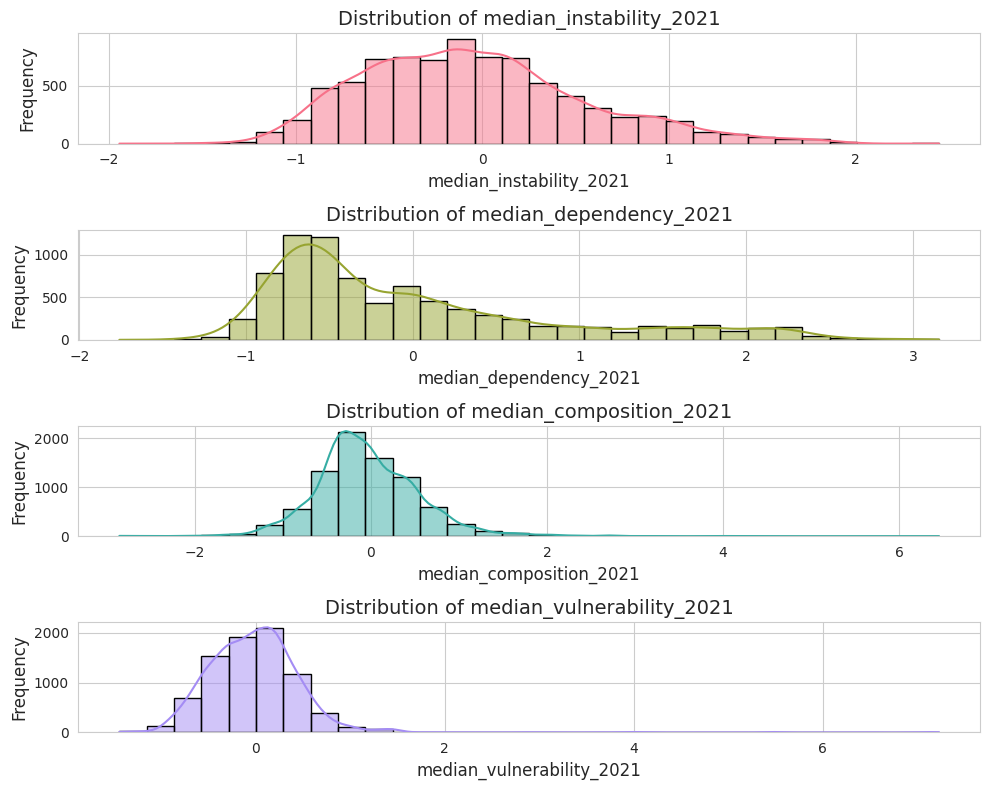

In [9]:

sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(features_of_interest))

# Create histograms for each selected feature
plt.figure(figsize=(10, 8))

for i, feature in enumerate(features_of_interest):
    plt.subplot(len(features_of_interest), 1, i + 1)
    sns.histplot(selected_data[feature], bins=30, kde=True, color=palette[i], edgecolor='black')
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True)

plt.tight_layout()
plt.show()


# Data Pre-Processing

## In this section we will be cleaning the data by imputing the missing values, dropping the data that is redundant and also subsetting the features to relevant features that would be used in this project.

In [10]:
data.shape

(23225, 89)

## Impute the missing values in CIMD Scores

In [11]:
# Define primary features and their corresponding score features
median_scores = [
    "median_instability_2021",
    "median_dependency_2021",
    "median_composition_2021",
    "median_vulnerability_2021"
]

primary_scores = [
    "Residential instability Scores",
    "Economic dependency Scores",
    "Ethno-cultural composition Scores",
    "Situational vulnerability Scores"
]

# Impute missing values in primary features using the corresponding scores
for primary, score in zip(median_scores, primary_scores):
    data[primary] = data.apply(
        lambda row: row[score] if pd.isnull(row[primary]) and not pd.isnull(row[score]) else row[primary],
        axis=1
    )

# Replace any remaining missing values with 0
data[median_scores] = data[median_scores].fillna(0)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23225 entries, 0 to 23224
Data columns (total 89 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           23224 non-null  float64
 1   ActiveYears                                                      23224 non-null  object 
 2   NumberOfActiveYears                                              23225 non-null  int64  
 3   ReportYear                                                       7372 non-null   float64
 4   NumberOfReports                                                  7372 non-null   float64
 5   NumberOfSubstances                                               7372 non-null   float64
 6   NumberOfMedia                                                    7372 non-null   float64
 7   NumberOfMeasureMethods                       

In [13]:
clean_data = data
clean_data.shape

(23225, 89)

## Let's drop the rows that have missing NpriID.

In [14]:
# CIMD scores
cimd_columns = [
    "median_instability_2021", "median_dependency_2021", "median_composition_2021", "median_vulnerability_2021"]

# identify rows with any CIMD score equal to 0
missing_cimd = (data[cimd_columns] == 0).any(axis=1)


# 'npri_id' for missing CIMD scores
missing_npri_ids = data[missing_cimd]["NpriID"].unique()

len(missing_npri_ids)

286

In [15]:
# Drop rows with these `NpriID` values
clean_data = data[~data["NpriID"].isin(missing_npri_ids)]

In [16]:
clean_data.shape

(22939, 89)

## Now let's subset the features in the dataset to focus on the ones that are used in this analysis.

In [17]:
clean_data = clean_data[["NpriID", "Carbon monoxide - Past 15 Years", "Ammonia (total) - Past 15 Years", "Sulphur dioxide - Past 15 Years","PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years",
                         "PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years","Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years",
                         "Volatile Organic Compounds (Total) - Past 15 Years", "median_instability_2021", "median_dependency_2021",
                         "median_composition_2021", "median_vulnerability_2021", "NAICSTitleEn", "Province", "geom"]]

In [18]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22939 entries, 0 to 23223
Data columns (total 15 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           22939 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  8517 non-null   float64
 2   Ammonia (total) - Past 15 Years                                  509 non-null    float64
 3   Sulphur dioxide - Past 15 Years                                  5576 non-null   float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      10390 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    11292 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  9100 non-null   float64
 7   Volatile Organic Compounds (Total) - Past 15 

##Let's Visualize the Distribution of Facilities across Provinces.

## The bar chart below, depicts the distribution of industrial facilities across Canadian provinces, with Alberta emerging as the province with the highest number of facilities, with 10,978 facilities.

## This dominance is followed by Ontario and Saskatchewan, which host 4,061 and 3,132 facilities, respectively. The chart underscores the concentration of industrial activity in these regions, reflecting their significant roles in Canada's industrial landscape.

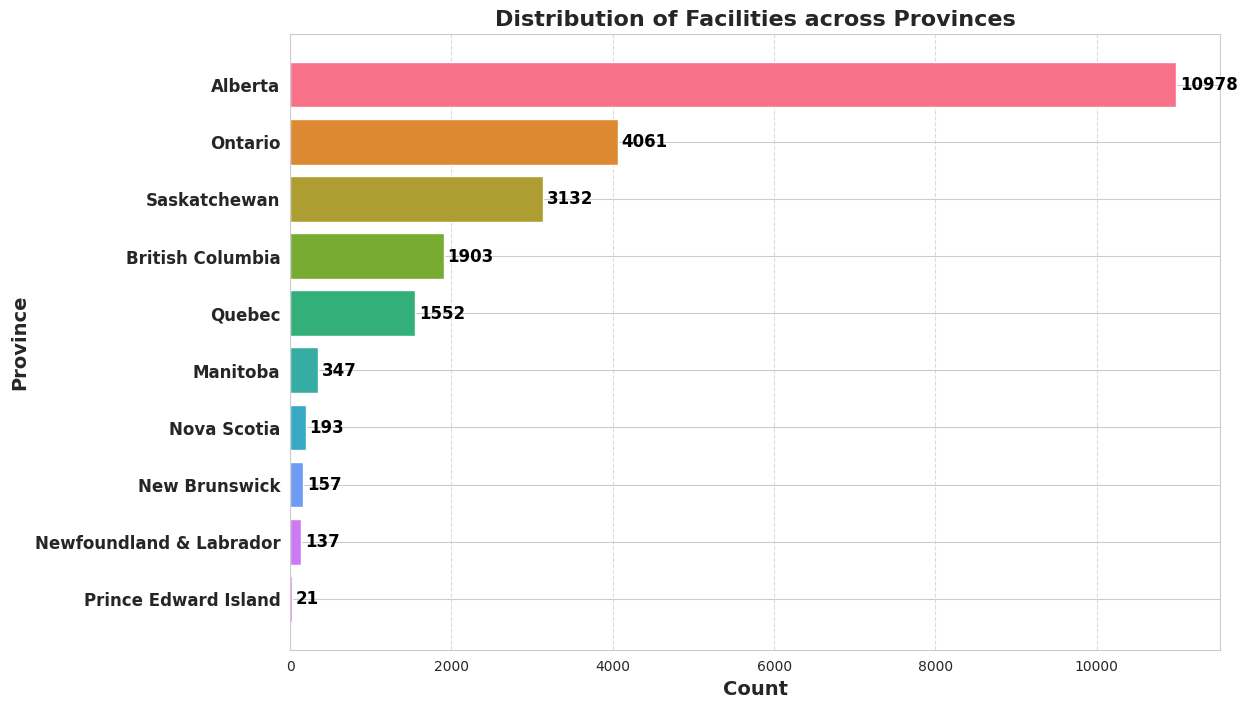

In [19]:

# Convert all values in the 'Province' column to strings
clean_data['Province'] = clean_data['Province'].astype(str)

# Filter out rows with 'None' values in the 'Province' column
filtered_data = clean_data[clean_data['Province'] != 'None']

# Calculate counts of each province
province_counts = filtered_data['Province'].value_counts().reset_index()
province_counts.columns = ['Province', 'Count']

# Plotting
plt.figure(figsize=(12, 8))
colors = sns.color_palette("husl", len(province_counts))  # Use seaborn color palette for different colors
bars = plt.barh(province_counts['Province'], province_counts['Count'], color=colors)

plt.xlabel('Count', fontsize=14, fontweight='bold')
plt.ylabel('Province', fontsize=14, fontweight='bold')
plt.title('Distribution of Facilities across Provinces', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count on top
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Set y-axis tick labels to be larger and bold
plt.yticks(fontsize=12, fontweight='bold')

# Add count labels next to the bars
for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}',
             va='center', ha='left', color='black', fontsize=12, fontweight='bold')

# Display the plot
plt.show()


## Let's Visualize the Distribution of all the 7 CAC's across the 10 Provinces in Canada


## *   In the following bar chart we can see the spread of the seven CACs across Canadian provinces is depicted, with each pollutant's contribution represented as a percentage of the total emissions across Canada. Alberta emerges as the leading province in the release of most pollutants, significantly contributing, for example, 54% of the total nitrogen oxides emissions in the country.

## *   This visualization underscores the regional differences in pollutant contributions, reflecting the varied industrial activities and environmental impacts across the provinces.



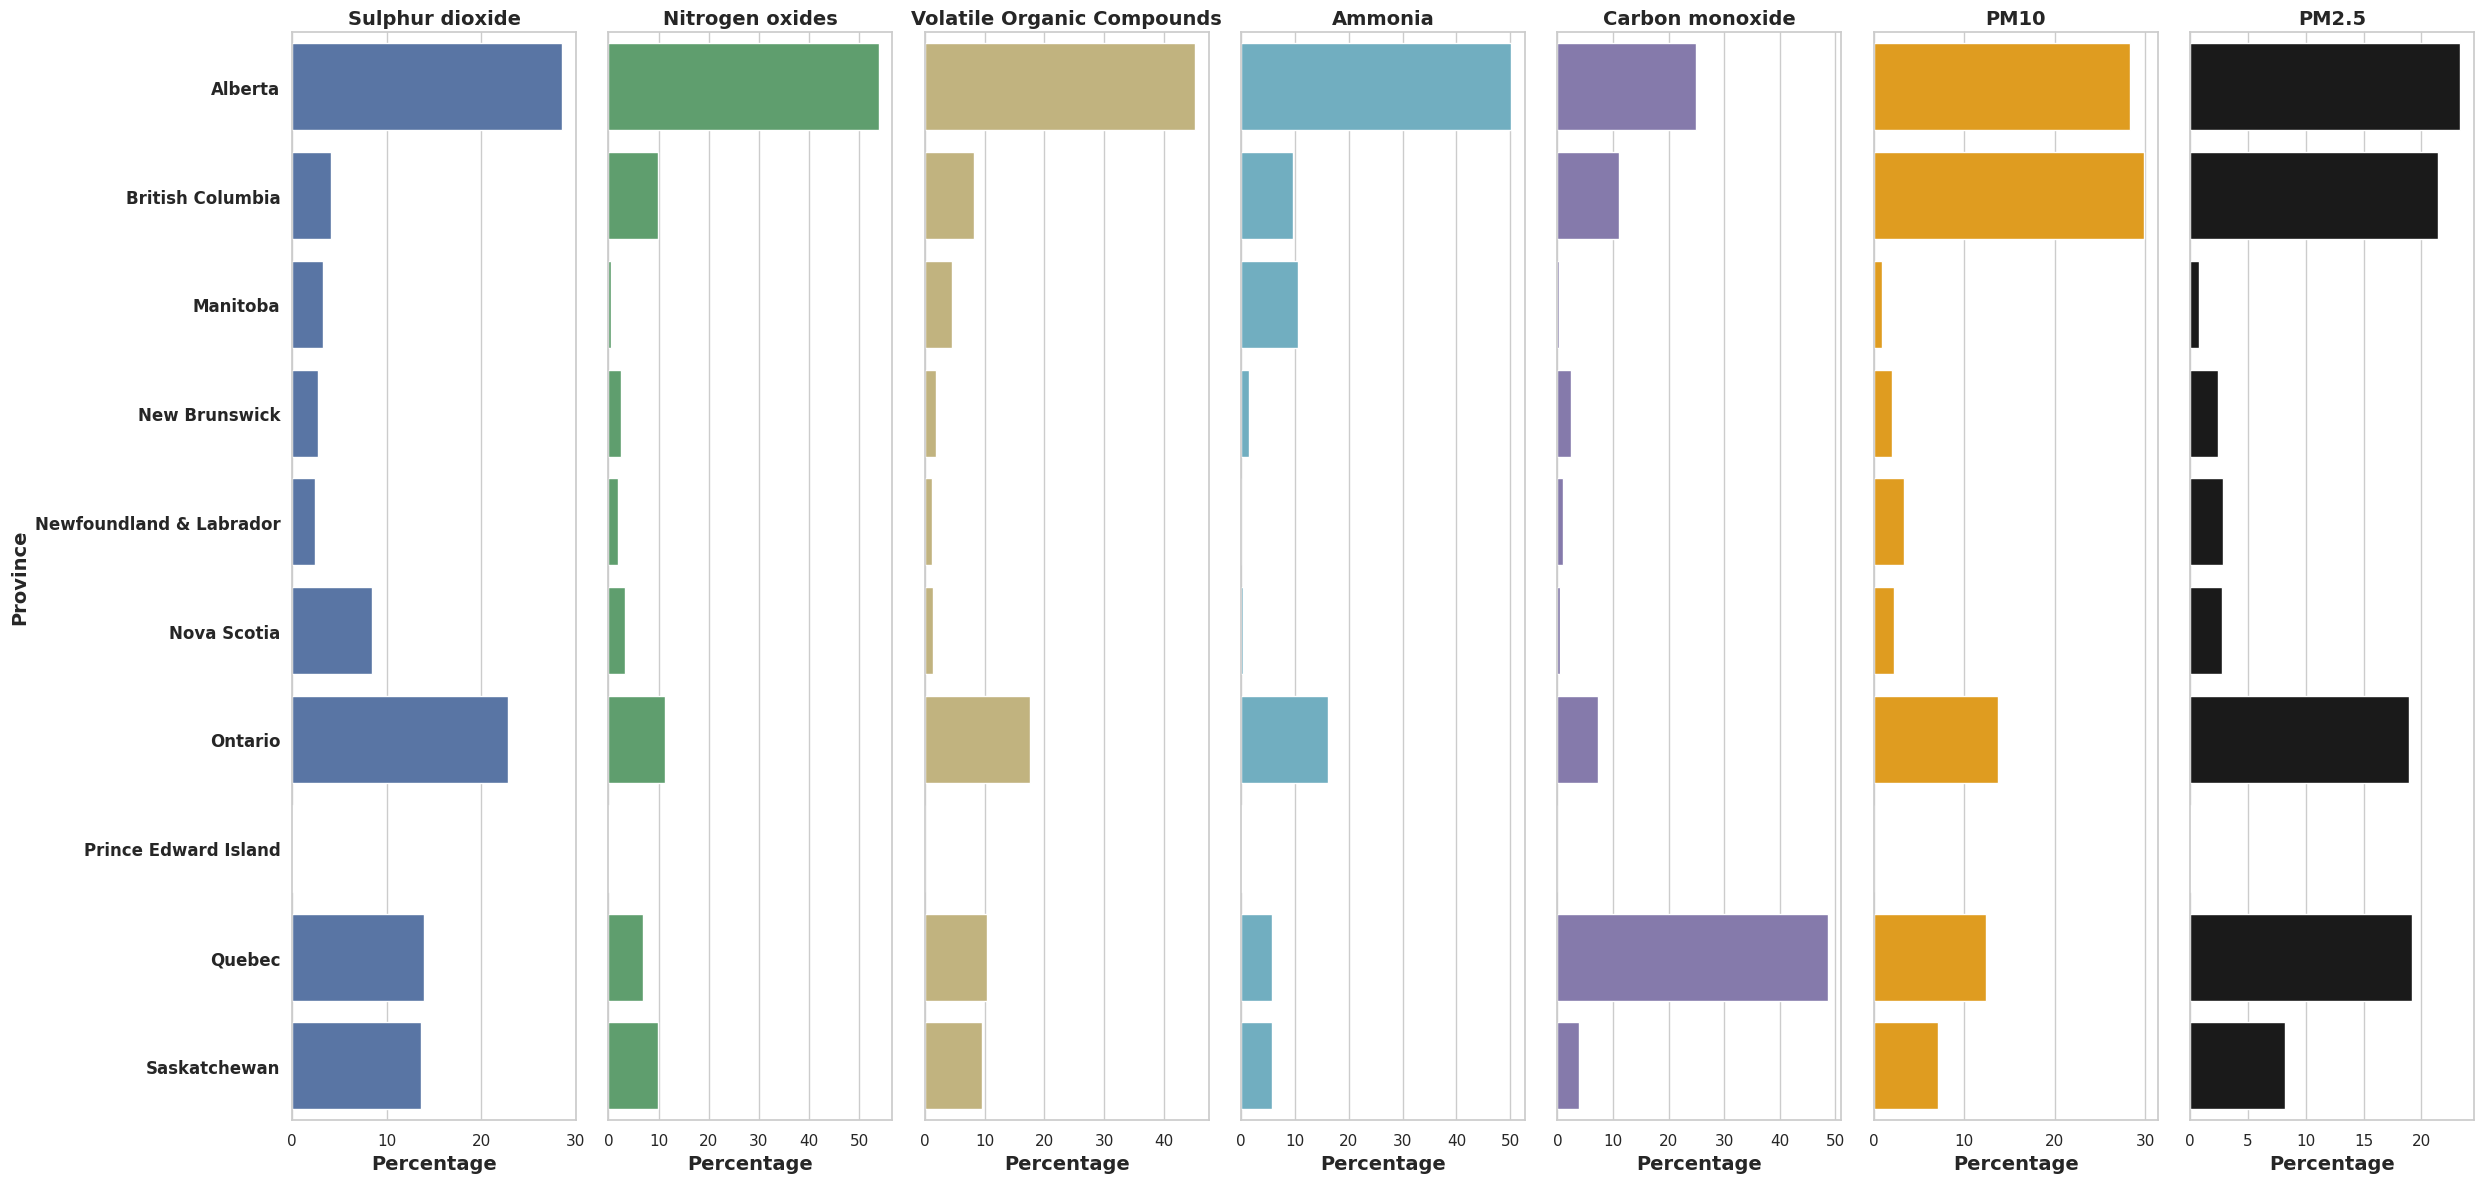

In [20]:
# Here we define pollutants and their shorter labels
pollutants = {
    'Sulphur dioxide - Past 15 Years': 'Sulphur dioxide',
    'Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years': 'Nitrogen oxides',
    'Volatile Organic Compounds (Total) - Past 15 Years': 'Volatile Organic Compounds',
    'Ammonia (total) - Past 15 Years': 'Ammonia',
    'Carbon monoxide - Past 15 Years': 'Carbon monoxide',
    'PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years': 'PM10',
    'PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years': 'PM2.5'
}

# Let's calculate the percentage of national emissions for each pollutant and province
emission_data = []
for pollutant, short_label in pollutants.items():
    total_emissions = filtered_data.groupby('Province')[pollutant].sum()
    total_national_emission = filtered_data[pollutant].sum()
    for province, total_emission in total_emissions.items():
        percentage = (total_emission / total_national_emission) * 100
        emission_data.append({
            'Province': province,
            'Pollutant': short_label,
            'Percentage': percentage
        })

# Convert to DataFrame for plotting
emission_df = pd.DataFrame(emission_data)
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=len(pollutants), sharey=True, figsize=(25, 12))

# Define colors for pollutants
pollutant_colors = {
    'Sulphur dioxide': 'b',
    'Nitrogen oxides': 'g',
    'Volatile Organic Compounds': 'y',
    'Ammonia': 'c',
    'Carbon monoxide': 'm',
    'PM10': 'orange',
    'PM2.5': 'k'
}

# Plot each pollutant in separate subplots
for i, (pollutant, short_label) in enumerate(pollutants.items()):
    sns.barplot(
        x='Percentage',
        y='Province',
        data=emission_df[emission_df['Pollutant'] == short_label],
        ax=axes[i],
        color=pollutant_colors[short_label]
    )
    axes[i].set_title(short_label, fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Percentage", fontsize=14, fontweight='bold')
    if i == 0:
        axes[i].set_ylabel('Province', fontsize=14, fontweight='bold')
    else:
        axes[i].set_ylabel('')
    axes[i].tick_params(axis='y', labelsize=12, labelrotation=0, width=1, length=5)
    for label in axes[i].get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()


In [21]:
# Extract the details of Alberta
alb_emission_df = emission_df[emission_df['Province'] == 'Alberta']

# Here we sort them in Descending order
alb_emission_df = alb_emission_df.sort_values(by='Percentage', ascending=False)
alb_emission_df['Percentage'] = alb_emission_df['Percentage'].round(1)


print(alb_emission_df)

   Province                   Pollutant  Percentage
10  Alberta             Nitrogen oxides        53.9
30  Alberta                     Ammonia        50.2
20  Alberta  Volatile Organic Compounds        45.2
0   Alberta             Sulphur dioxide        28.6
50  Alberta                        PM10        28.4
40  Alberta             Carbon monoxide        25.0
60  Alberta                       PM2.5        23.4


In [22]:
# Extract the details of Prince Edward Island
pei_emission_df = emission_df[emission_df['Province'] == 'Prince Edward Island']

# Here we sort them in Descending order
pei_emission_df = pei_emission_df.sort_values(by='Percentage', ascending=False)
pei_emission_df['Percentage'] = pei_emission_df['Percentage'].round(3)

print(pei_emission_df)

                Province                   Pollutant  Percentage
37  Prince Edward Island                     Ammonia       0.077
67  Prince Edward Island                       PM2.5       0.050
7   Prince Edward Island             Sulphur dioxide       0.043
17  Prince Edward Island             Nitrogen oxides       0.037
57  Prince Edward Island                        PM10       0.034
27  Prince Edward Island  Volatile Organic Compounds       0.019
47  Prince Edward Island             Carbon monoxide       0.008


In [23]:
#Fill missing values with zero
filtered_data = clean_data.fillna(0)

In [24]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22939 entries, 0 to 23223
Data columns (total 15 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           22939 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  22939 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  22939 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  22939 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      22939 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    22939 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  22939 non-null  float64
 7   Volatile Organic Compounds (Total) - Past 15 

# Distribution of CIMD scores after filling missing values

In [25]:
features_of_interest = ["median_instability_2021", "median_dependency_2021", "median_composition_2021", "median_vulnerability_2021"]  # Replace with your feature names
selected_data = clean_data[features_of_interest]

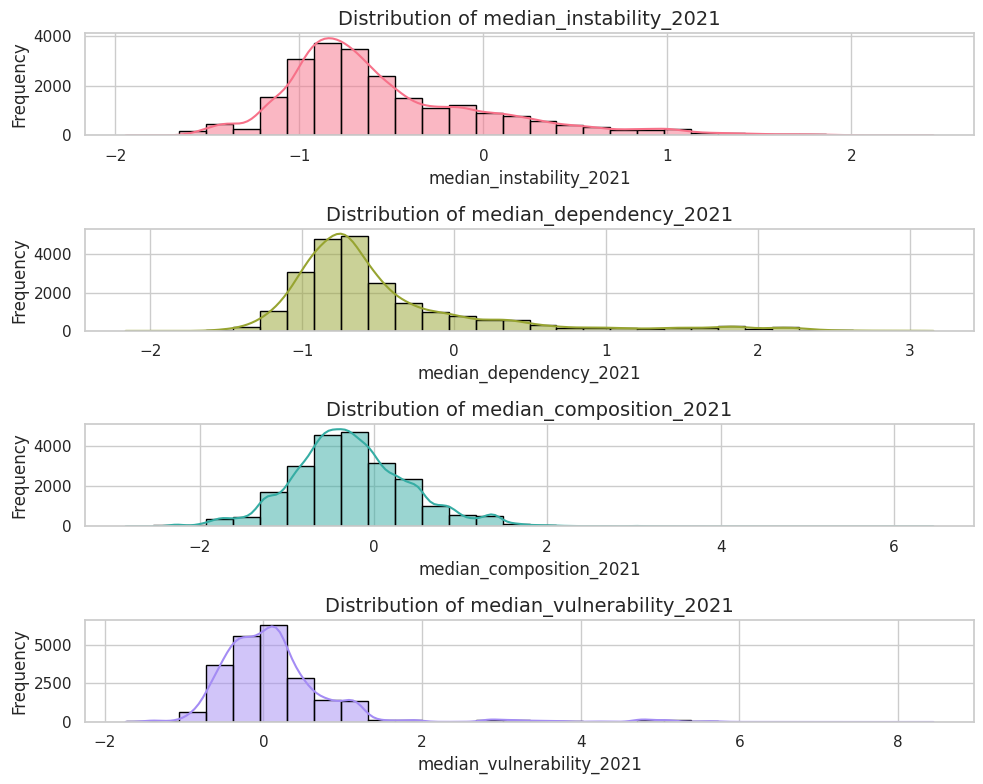

In [26]:
sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(features_of_interest))

# Create histograms for each selected feature
plt.figure(figsize=(10, 8))

for i, feature in enumerate(features_of_interest):
    plt.subplot(len(features_of_interest), 1, i + 1)
    sns.histplot(selected_data[feature], bins=30, kde=True, color=palette[i], edgecolor='black')
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True)

plt.tight_layout()
plt.show()


## Transforming the Pollutant values from Tonnes to Kilograms

In [27]:
# List of features with pollution values in tonnes
pollution_columns = [
    'Carbon monoxide - Past 15 Years',
    'Ammonia (total) - Past 15 Years',
    'Sulphur dioxide - Past 15 Years',
    'PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years',
    'PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years',
    'Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years',
    'Volatile Organic Compounds (Total) - Past 15 Years'
]

# Here we convert pollution values from tonnes to kilograms
filtered_data[pollution_columns] = filtered_data[pollution_columns].apply(lambda x: x * 1000)

In [28]:
filtered_data.head()

,NpriID,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021,NAICSTitleEn,Province,geom
0,1.0,38079730.0,1138163.0,12474560.0,4596971.0,2686374.0,19862460.0,231560.0,-0.582091,-0.931834,0.118129,0.040765,Chemical pulp mills,Alberta,0101000020130D000028E29B8308B45241F3F774082887...
1,4.0,4741056.0,0.0,432698.0,1122348.0,613633.0,433719.0,0.0,-0.136354,-0.801004,1.080914,2.125086,0,Manitoba,0101000020130D0000A9AA3F46037B5641201B3DE8979E...
2,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.303520,0.458542,-0.192082,-0.102991,0,Quebec,0101000020130D00002A1012D0FF0E5D418BD048994511...
3,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.435101,-0.678222,0.147319,0.360477,0,Ontario,0101000020130D0000AF42A83CF2515B41C46487E74FA7...
4,11.0,127239.0,356.7,0.0,21589.3,14451.5,35039.1,49581.8,0.171245,0.263431,-0.305970,0.148640,Resin and synthetic rubber manufacturing,Alberta,0101000020130D00000DF63146E55952410A5265C49896...


In [29]:

clean_data = filtered_data

clean_data.shape

(22939, 15)

In [30]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22939 entries, 0 to 23223
Data columns (total 15 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           22939 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  22939 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  22939 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  22939 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      22939 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    22939 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  22939 non-null  float64
 7   Volatile Organic Compounds (Total) - Past 15 

In [31]:
# Renaming columns in clean_data to match final_df
clean_data = clean_data.rename(columns={
    "NAICSTitleEn": "industry_type",
    "geom": "geometry"
})

# Distribution of pollution across Industry Types

## This visualization highlights the dominant polluting industries for each CAC, highlighting the significant role of specific sectors in national pollutant levels.

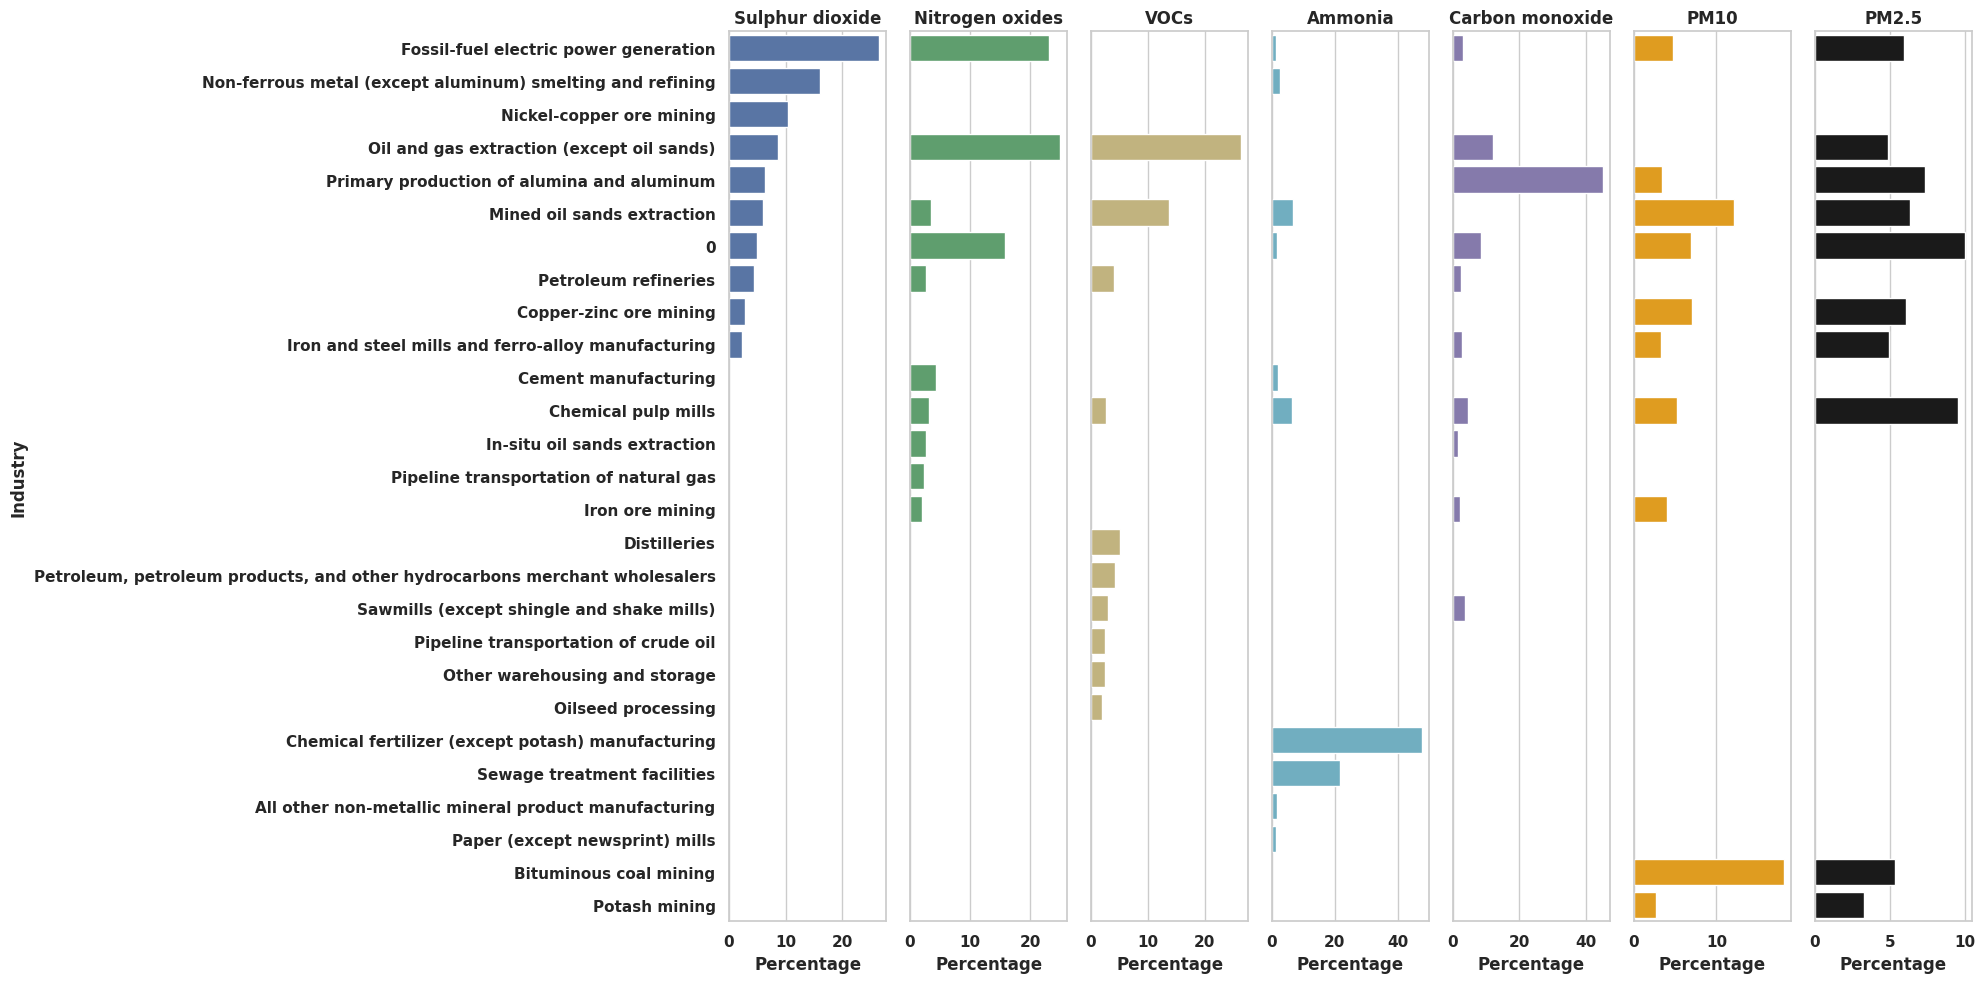

In [32]:
# Here we define pollutants and their shorter labels
pollutants = {
    'Sulphur dioxide - Past 15 Years': 'Sulphur dioxide',
    'Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years': 'Nitrogen oxides',
    'Volatile Organic Compounds (Total) - Past 15 Years': 'VOCs',
    'Ammonia (total) - Past 15 Years': 'Ammonia',
    'Carbon monoxide - Past 15 Years': 'Carbon monoxide',
    'PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years': 'PM10',
    'PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years': 'PM2.5'
}

# Let's calculate the percentage of national emissions for each pollutant and industry
emission_data = []
for pollutant, short_label in pollutants.items():
    total_emissions = clean_data.groupby('industry_type')[pollutant].sum()
    total_national_emission = clean_data[pollutant].sum()
    top_10_industries = total_emissions.nlargest(10)
    for industry, total_emission in top_10_industries.items():
        percentage = (total_emission / total_national_emission) * 100
        emission_data.append({
            'Industry': industry,
            'Pollutant': short_label,
            'Percentage': percentage
        })

# Convert it to a dataframe to enable plotting
emission_df = pd.DataFrame(emission_data)
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=len(pollutants), sharey=True, figsize=(20, 10))

# Define colors for each pollutant
pollutant_colors = {
    'Sulphur dioxide': 'b',
    'Nitrogen oxides': 'g',
    'VOCs': 'y',
    'Ammonia': 'c',
    'Carbon monoxide': 'm',
    'PM10': 'orange',
    'PM2.5': 'k'
}

# Plot each pollutant in separate subplots
for i, (pollutant, short_label) in enumerate(pollutants.items()):
    sns.barplot(
        x='Percentage',
        y='Industry',
        data=emission_df[emission_df['Pollutant'] == short_label],
        ax=axes[i],
        color=pollutant_colors[short_label]
    )
    axes[i].set_title(short_label, fontweight='bold')
    axes[i].set_xlabel("Percentage", fontweight='bold')
    if i == 0:
        axes[i].set_ylabel('Industry', fontweight='bold')
    else:
        axes[i].set_ylabel('')
    for label in axes[i].get_yticklabels():
        label.set_fontweight('bold')
    for label in axes[i].get_xticklabels():
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()


## Filter rows where all pollutant values are 0

In [33]:
# List of pollutant columns
pollutant_columns = [
    'Carbon monoxide - Past 15 Years',
    'Ammonia (total) - Past 15 Years',
    'Sulphur dioxide - Past 15 Years',
    'PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years',
    'PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years',
    'Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years',
    'Volatile Organic Compounds (Total) - Past 15 Years'
]

# Filter rows where all pollutant values are 0
null_emission = clean_data[(clean_data[pollutant_columns] == 0).all(axis=1)]
null_emission.shape

(7794, 15)

In [34]:
null_emission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7794 entries, 2 to 23213
Data columns (total 15 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           7794 non-null   float64
 1   Carbon monoxide - Past 15 Years                                  7794 non-null   float64
 2   Ammonia (total) - Past 15 Years                                  7794 non-null   float64
 3   Sulphur dioxide - Past 15 Years                                  7794 non-null   float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      7794 non-null   float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    7794 non-null   float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  7794 non-null   float64
 7   Volatile Organic Compounds (Total) - Past 15 Y

## Manipulate these Null emission data by adding them as Cluster 4

In [35]:
null_emission['Cluster'] = 4

<ipython-input-35-72c870d9c06b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  null_emission['Cluster'] = 4


In [36]:
null_emission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7794 entries, 2 to 23213
Data columns (total 16 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           7794 non-null   float64
 1   Carbon monoxide - Past 15 Years                                  7794 non-null   float64
 2   Ammonia (total) - Past 15 Years                                  7794 non-null   float64
 3   Sulphur dioxide - Past 15 Years                                  7794 non-null   float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      7794 non-null   float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    7794 non-null   float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  7794 non-null   float64
 7   Volatile Organic Compounds (Total) - Past 15 Y

In [37]:
clean_data.shape

(22939, 15)

## Drop rows where all pollutant values are 0 from the original dataframe

In [38]:
# Drop rows where all pollutant values are 0 from the original clean_dataframe
clean_data = clean_data[(clean_data[pollutant_columns] != 0).any(axis=1)]

# Display the modified original clean_dataframe
clean_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 15145 entries, 0 to 23223
Data columns (total 15 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           15145 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  15145 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  15145 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  15145 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      15145 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    15145 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  15145 non-null  float64
 7   Volatile Organic Compounds (Total) - Past 15 

## Here in the below table we can observe that all the rows have atleast one vaule for the 7 pollutants.

In [39]:
clean_data.head()

,NpriID,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021,industry_type,Province,geometry
0,1.0,38079730.0,1138163.0,12474560.0,4596971.0,2686374.0,19862460.0,231560.0,-0.582091,-0.931834,0.118129,0.040765,Chemical pulp mills,Alberta,0101000020130D000028E29B8308B45241F3F774082887...
1,4.0,4741056.0,0.0,432698.0,1122348.0,613633.0,433719.0,0.0,-0.136354,-0.801004,1.080914,2.125086,0,Manitoba,0101000020130D0000A9AA3F46037B5641201B3DE8979E...
4,11.0,127239.0,356.7,0.0,21589.3,14451.5,35039.1,49581.8,0.171245,0.263431,-0.305970,0.148640,Resin and synthetic rubber manufacturing,Alberta,0101000020130D00000DF63146E55952410A5265C49896...
6,15.0,21000.0,0.0,0.0,0.0,3023.0,287886.0,61120.0,-0.214426,0.197338,0.356953,-0.034882,"Coating, engraving, cold and heat treating and...",Ontario,0101000020130D0000AA6163DB297B5B415CA8C15202C2...
7,18.0,0.0,0.0,0.0,63463.3,32544.0,0.0,0.0,0.324293,-0.906240,0.317295,-0.102174,0,Quebec,0101000020130D00008CD8842C68665D41970BC2DB9697...


## Prepare the data for Clustering

In [40]:
# Separate the NpriID column from the features
npri_id = clean_data['NpriID']
del clean_data['NpriID']

In [41]:
# Here we remove the categorical features and retain the numerical features to facilitate clustering analysis

industry_titles = clean_data['industry_type']
del clean_data['industry_type']

Province = clean_data['Province']
del clean_data['Province']

geometry = clean_data['geometry']
del clean_data['geometry']

In [42]:
clean_data.shape

(15145, 11)

## Data Normalization

## Here we normalize the data using the Min-Max method in order to account for outliers in pollutant and CIMD values.

In [43]:
# Define desired minimum and maximum values for scaling
desired_min = 0
desired_max = 1

# Standardize the data
clean_datastd = (clean_data - clean_data.min(axis=0)) / (clean_data.max(axis=0) - clean_data.min(axis=0))

# Scale the standardized data to the desired range
clean_data_scaled = clean_datastd * (desired_max - desired_min) + desired_min

clean_data_scaled.head()


,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021
0,0.028953,0.036555,0.008528,0.034565,0.068643,0.076101,0.033997,0.314185,0.231406,0.412442,0.198048
1,0.003605,0.000000,0.000296,0.008439,0.015680,0.001662,0.000000,0.417007,0.256001,0.545889,0.430469
4,0.000097,0.000011,0.000000,0.000162,0.000369,0.000134,0.007280,0.487963,0.456111,0.353660,0.210077
6,0.000016,0.000000,0.000000,0.000000,0.000077,0.001103,0.008974,0.398997,0.443685,0.445544,0.189613
7,0.000000,0.000000,0.000000,0.000477,0.000832,0.000000,0.000000,0.523268,0.236217,0.440047,0.182109


In [44]:

features_of_interest = ["median_instability_2021", "median_dependency_2021", "median_composition_2021", "median_vulnerability_2021"]
selected_data = clean_data_scaled[features_of_interest]

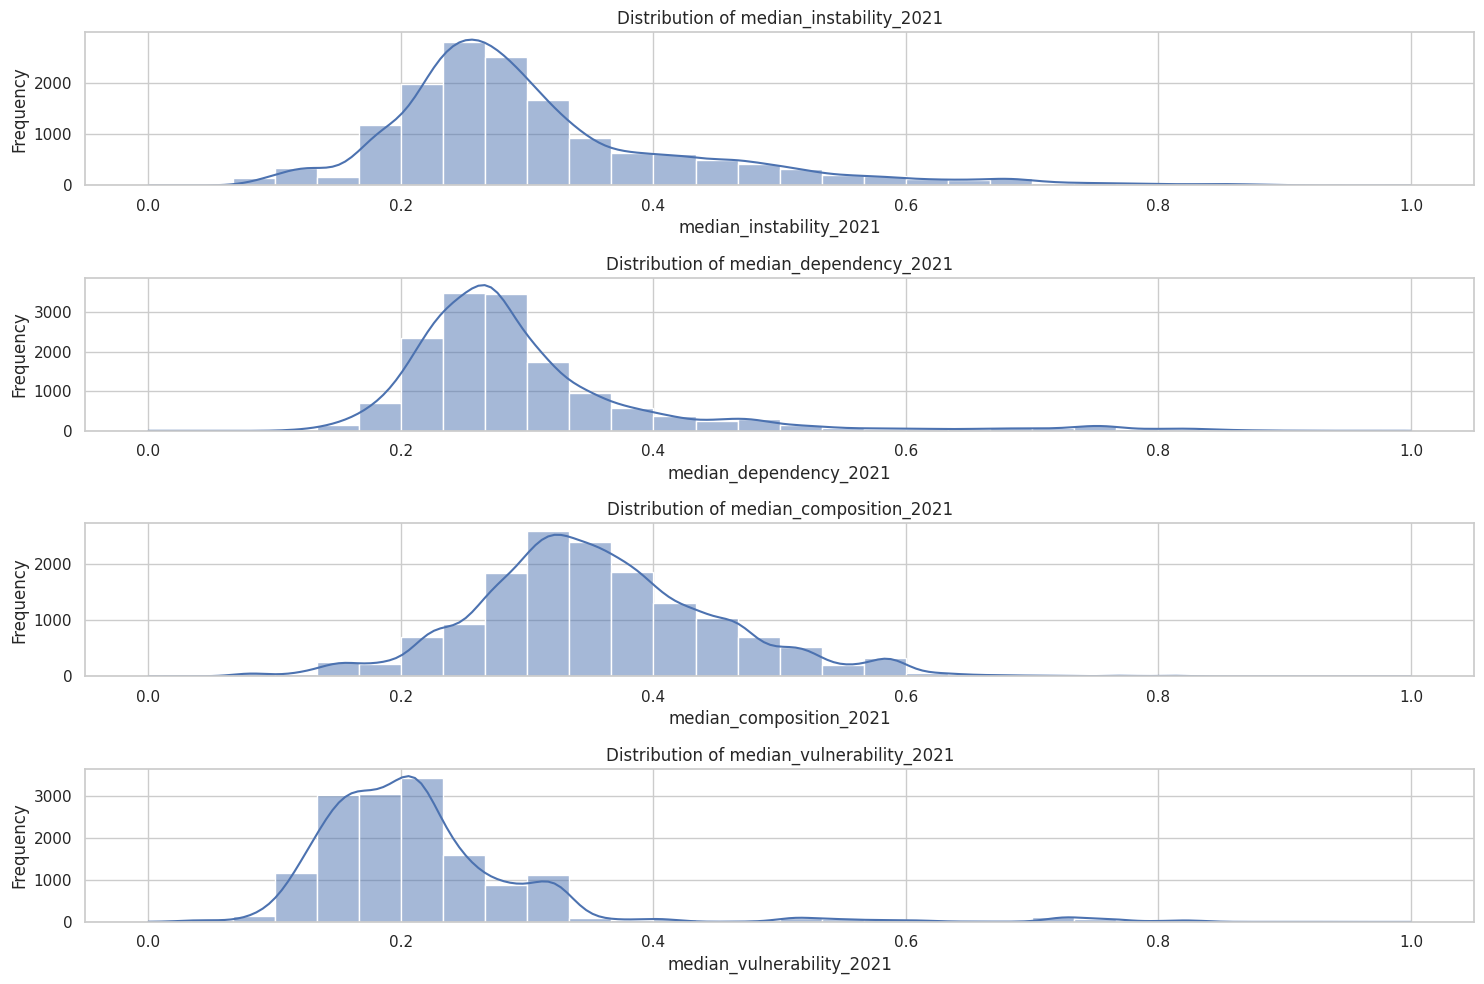

In [45]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_of_interest):
    plt.subplot(len(features_of_interest), 1, i + 1)
    sns.histplot(selected_data[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# By visualizing the plots below we can see that for k=4, we have the highest silhouette coefficient score.

For n_clusters = 2, The average silhouette_score is: 0.3938096628549193
For n_clusters = 3, The average silhouette_score is: 0.40950292446246495
For n_clusters = 4, The average silhouette_score is: 0.4155014114707601
For n_clusters = 5, The average silhouette_score is: 0.29448110789803195
For n_clusters = 6, The average silhouette_score is: 0.260093081529628
For n_clusters = 7, The average silhouette_score is: 0.2887890620389181


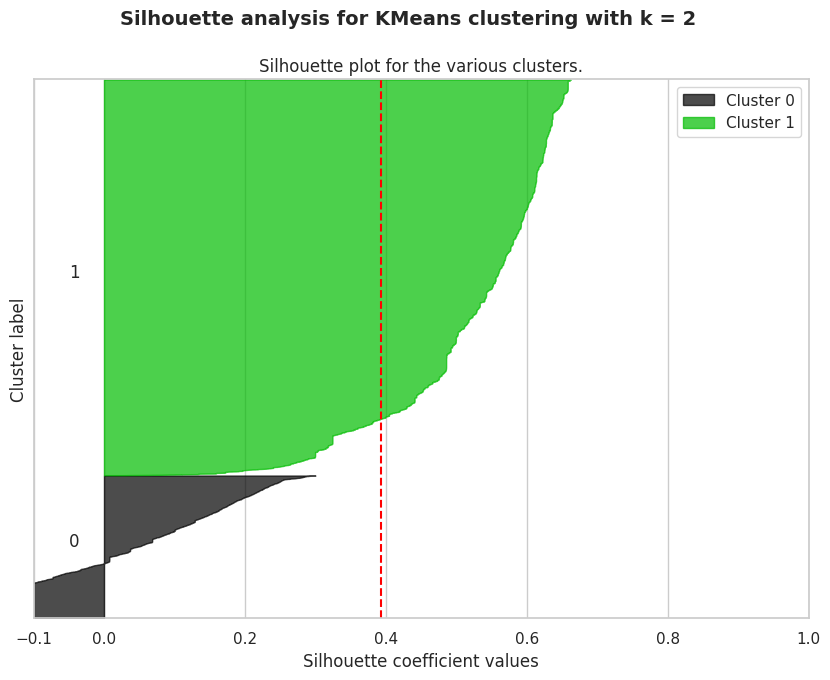

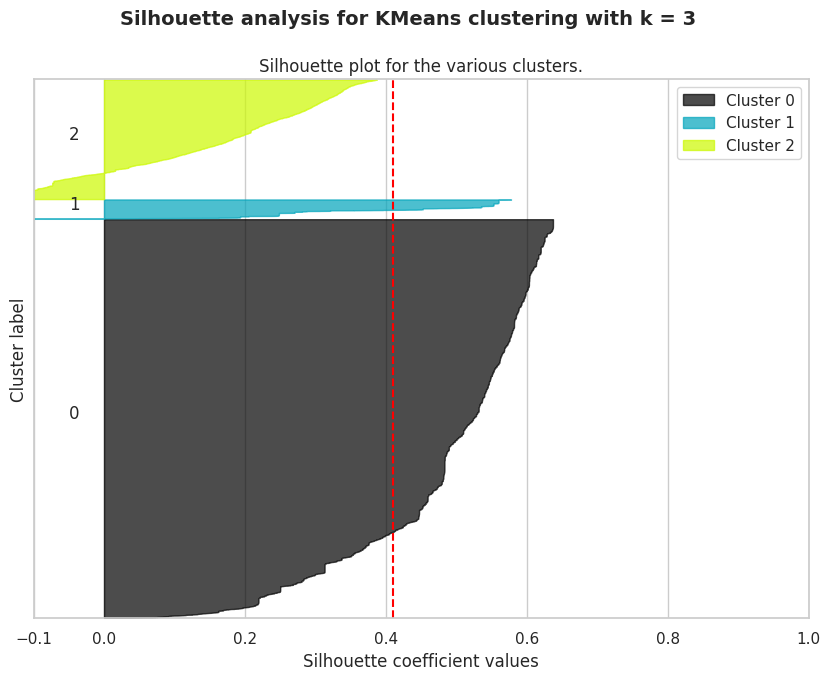

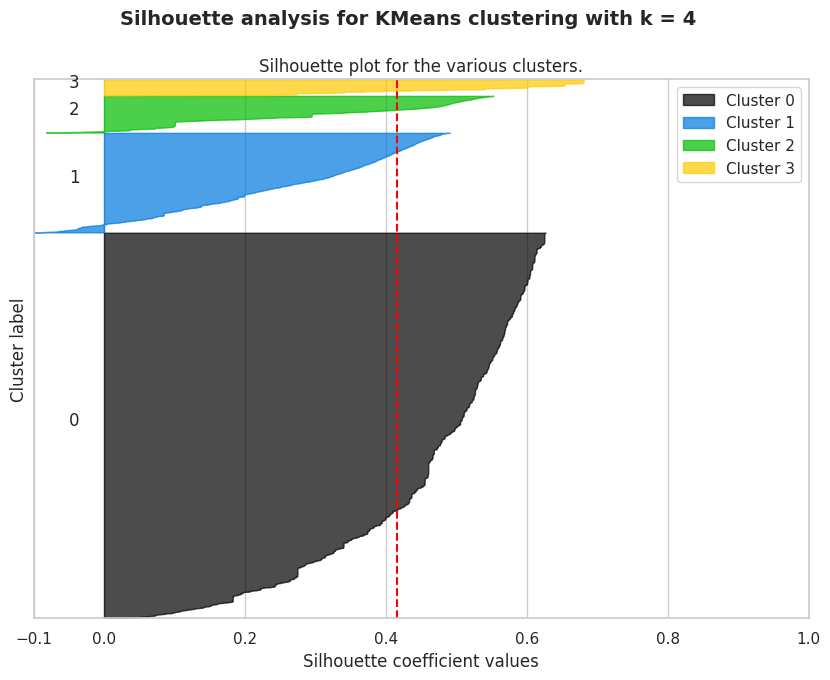

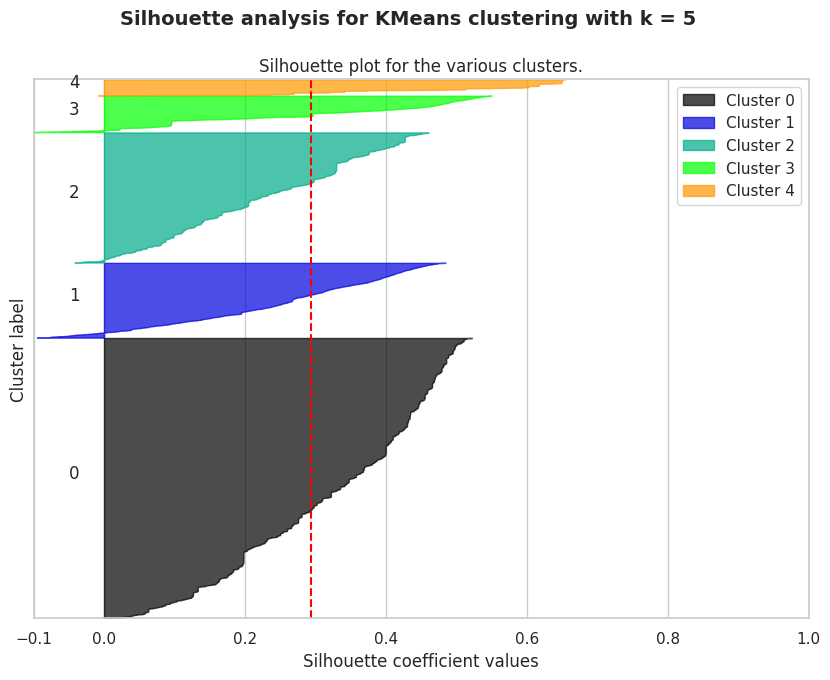

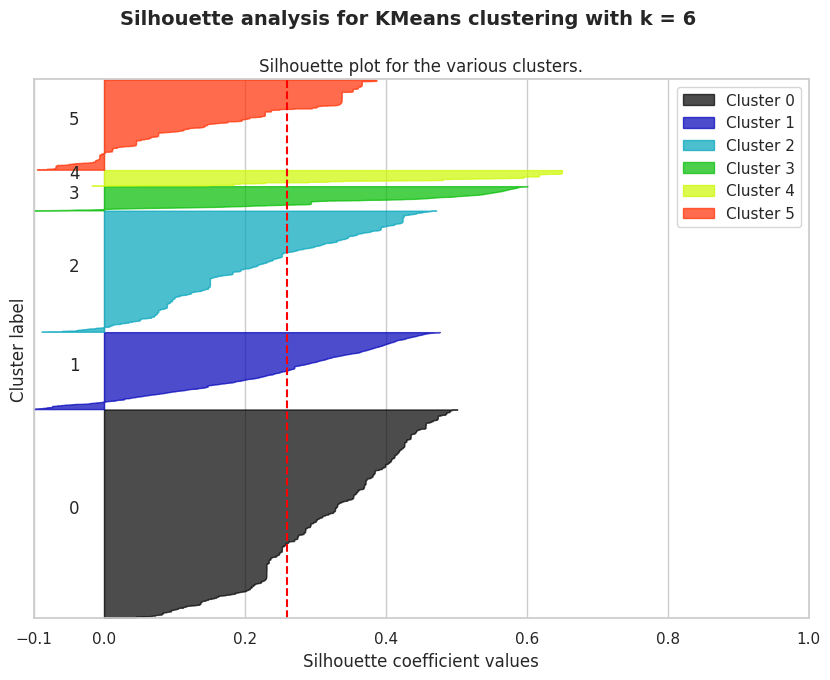

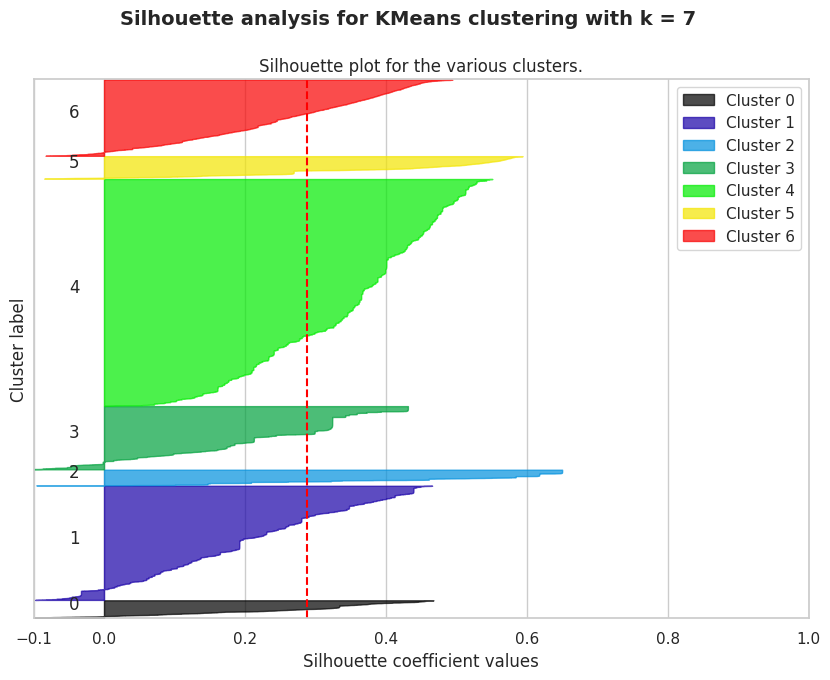

In [46]:
# Here we convert the data into a numpy array, this will help in the iterative process of clustering
clean_data_scaled = np.array(clean_data_scaled)

# Define the range of cluster numbers
range_n_clusters = [2, 3, 4, 5, 6, 7]

for n_clusters in range_n_clusters:
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)

    # Here we define the limits of x-axis and y-axis
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(clean_data_scaled) + (n_clusters + 1) * 10])

    # Set ep kmeans clustering
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(clean_data_scaled)

    # The silhouette_score gives the average value for all the samples
    silhouette_avg = silhouette_score(clean_data_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, The average silhouette_score is: {silhouette_avg}")

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(clean_data_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7, label=f'Cluster {i}')

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10

    ax1.set_title("Silhouette plot for the various clusters.")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax1.legend(loc='upper right')

    plt.suptitle(f"Silhouette analysis for KMeans clustering with k = {n_clusters}", fontsize=14, fontweight="bold")

plt.show()


In [47]:
clean_data_scaled.shape

(15145, 11)

In [48]:
# Convert scaled data to a DataFrame
clean_data_scaled = pd.DataFrame(clean_data_scaled, columns=clean_data.columns)


# K-Means Clustering

## K-means clustering is a widely used partitioning method in data analysis that aims to divide a dataset into a specified number of clusters (k), where each data point belongs to the cluster with the nearest mean value. Its simplicity allows for easy interpretation of the results.

In [49]:
# K-means clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(clean_data_scaled)

KMeans(n_clusters=4, random_state=42)

In [50]:
# Add the cluster labels
clean_data_scaled['Cluster'] = kmeans.labels_

In [51]:
clean_data_scaled.shape

(15145, 12)

## Here we add cluster labels to raw data and plot box plots for each features and then observe their distribution over the clusters.


In [52]:
clean_data['Cluster'] = kmeans.labels_

In [53]:
from scipy.stats import rankdata

def calculate_percentile_ranks(df):
    rank_df = df.copy()
    for col in df.columns:
        rank_df[col] = rankdata(df[col], method='average') / len(df[col]) * 100
    return rank_df

# Assuming your dataset has a 'Cluster' column
cluster_column = 'Cluster'
features = clean_data.drop(columns=[cluster_column])

percentile_ranks = calculate_percentile_ranks(features)
percentile_ranks[cluster_column] = clean_data[cluster_column]


In [54]:
data_melted = pd.melt(percentile_ranks, id_vars=[cluster_column], var_name="Feature", value_name="Percentile_Rank")


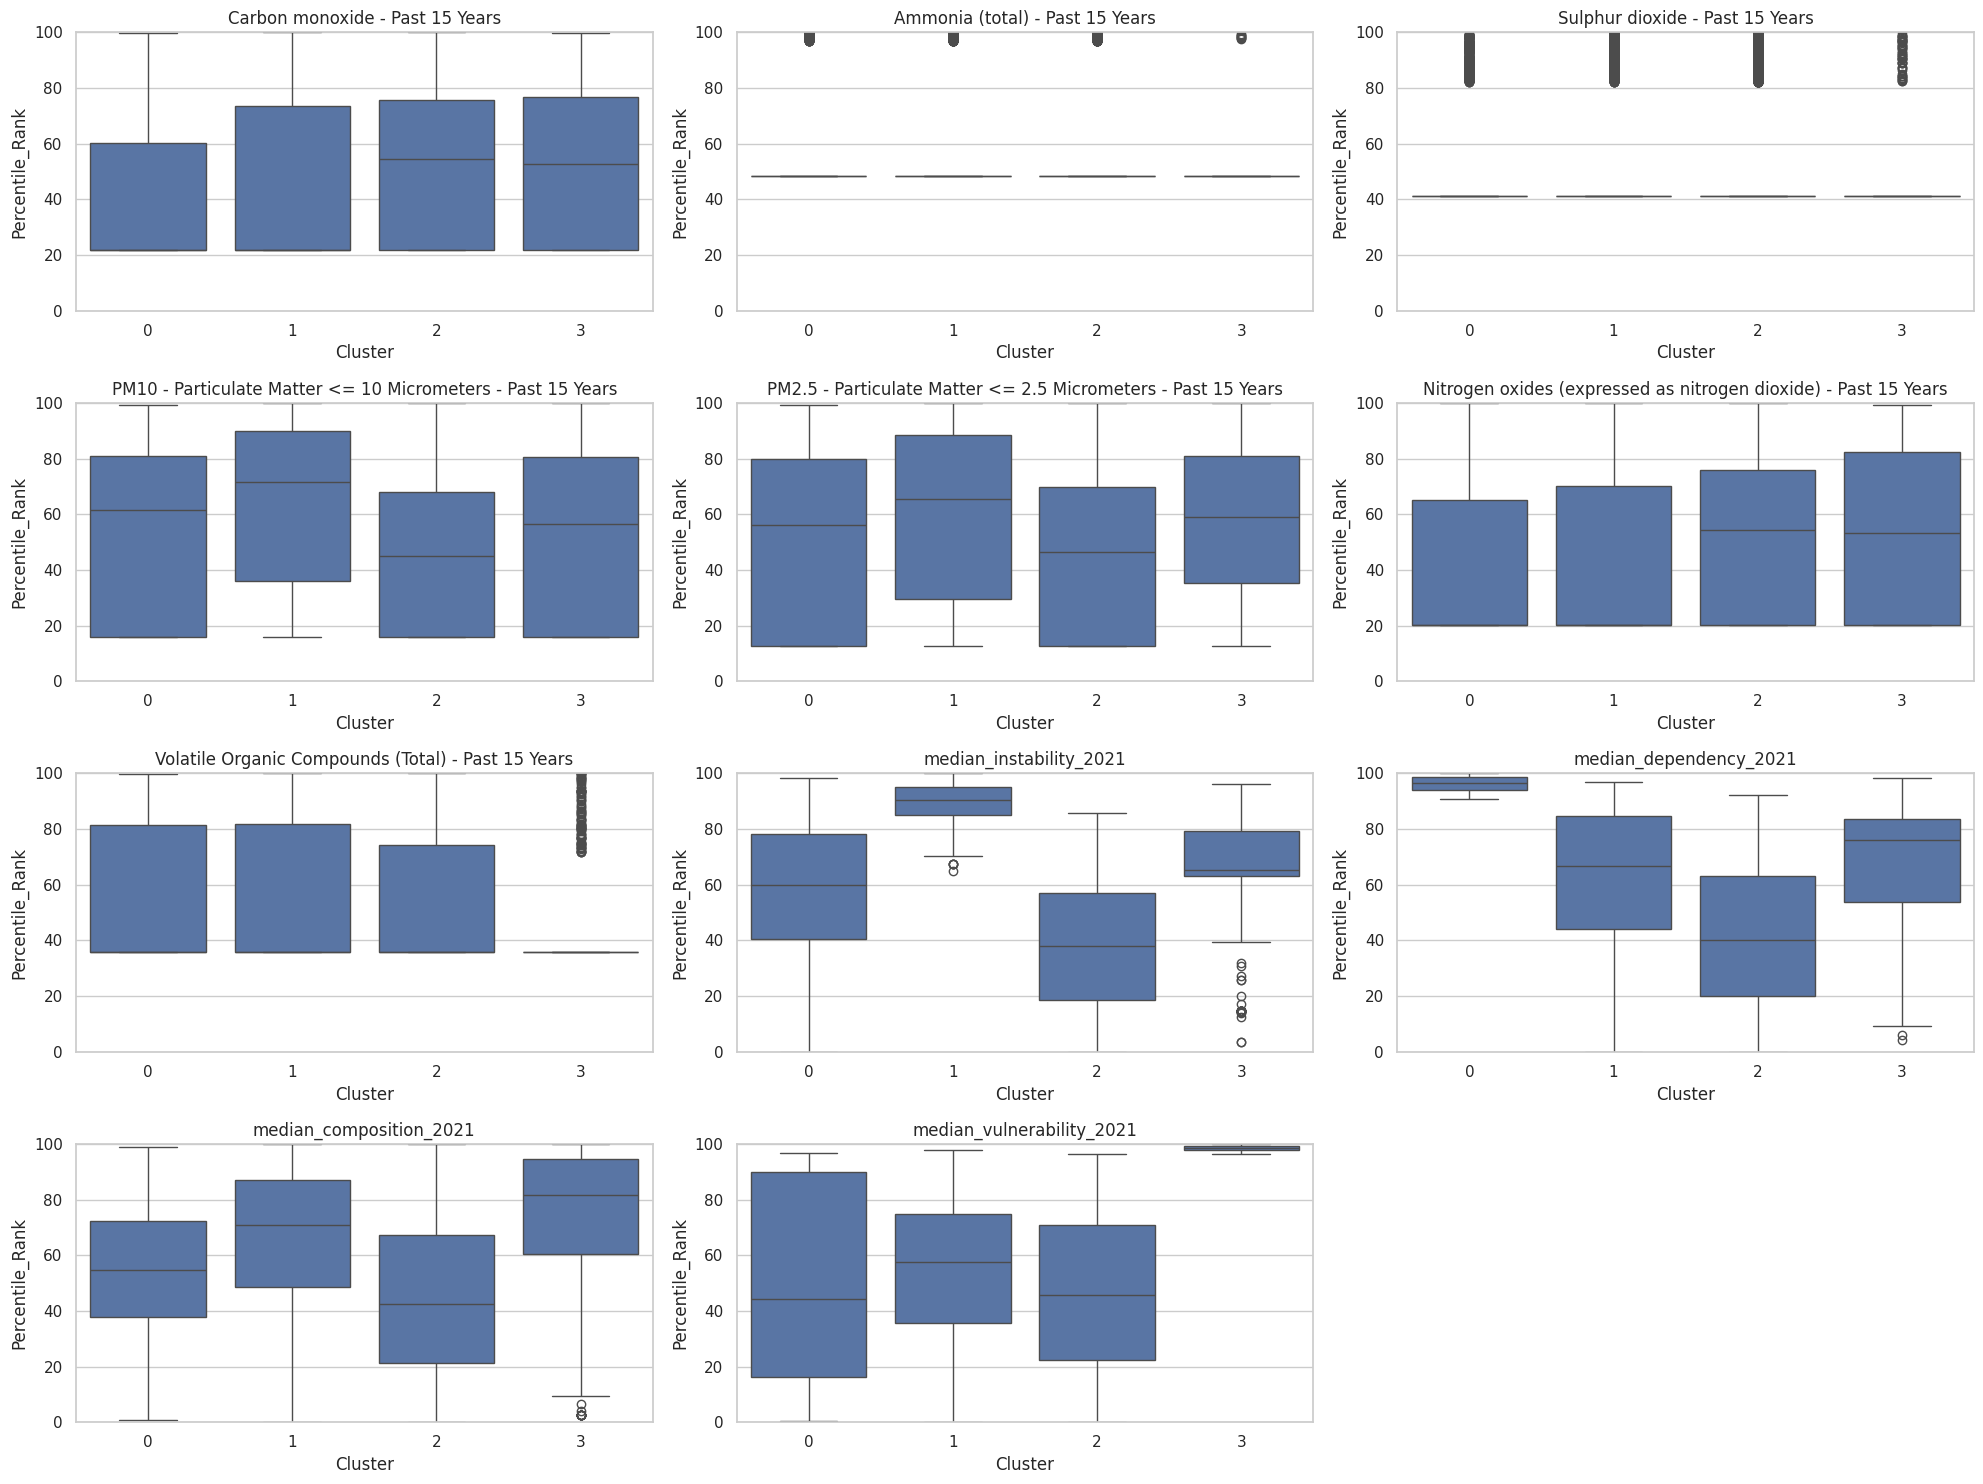

In [55]:
features = data_melted['Feature'].unique()
num_features = len(features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.boxplot(x="Cluster", y="Percentile_Rank", data=data_melted[data_melted['Feature'] == feature])
    plt.title(feature)
    plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [56]:
# This is the scaled data
clean_data_scaled.head()

,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021,Cluster
0,0.028953,0.036555,0.008528,0.034565,0.068643,0.076101,0.033997,0.314185,0.231406,0.412442,0.198048,2
1,0.003605,0.000000,0.000296,0.008439,0.015680,0.001662,0.000000,0.417007,0.256001,0.545889,0.430469,1
2,0.000097,0.000011,0.000000,0.000162,0.000369,0.000134,0.007280,0.487963,0.456111,0.353660,0.210077,1
3,0.000016,0.000000,0.000000,0.000000,0.000077,0.001103,0.008974,0.398997,0.443685,0.445544,0.189613,1
4,0.000000,0.000000,0.000000,0.000477,0.000832,0.000000,0.000000,0.523268,0.236217,0.440047,0.182109,1


In [57]:
clean_data_scaled['Cluster'].value_counts()

,count
Cluster,
2,10837
1,2827
0,1033
3,448


In [58]:
# Reassigning the data to a separate variable
final_data = clean_data_scaled

In [59]:
final_data.head()

,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021,Cluster
0,0.028953,0.036555,0.008528,0.034565,0.068643,0.076101,0.033997,0.314185,0.231406,0.412442,0.198048,2
1,0.003605,0.000000,0.000296,0.008439,0.015680,0.001662,0.000000,0.417007,0.256001,0.545889,0.430469,1
2,0.000097,0.000011,0.000000,0.000162,0.000369,0.000134,0.007280,0.487963,0.456111,0.353660,0.210077,1
3,0.000016,0.000000,0.000000,0.000000,0.000077,0.001103,0.008974,0.398997,0.443685,0.445544,0.189613,1
4,0.000000,0.000000,0.000000,0.000477,0.000832,0.000000,0.000000,0.523268,0.236217,0.440047,0.182109,1


# Principal Component Analysis (PCA)

## Here we perform PCA to visulaize 2 dimensional cluster formation.


In [60]:
from sklearn.decomposition import PCA

# Perform PCA to reduce the dimensionality for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(final_data)
pca_df = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])

In [61]:
# Add the cluster labels to the PCA dataframe
pca_df['cluster'] = kmeans.labels_

<ipython-input-62-ba5ea515216e>:3: UserWarning: 
The markers list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=pca_df, x='principal_component_1', y='principal_component_2', hue='cluster', palette='deep', style='cluster', s=100, edgecolor='k', markers= 'o')


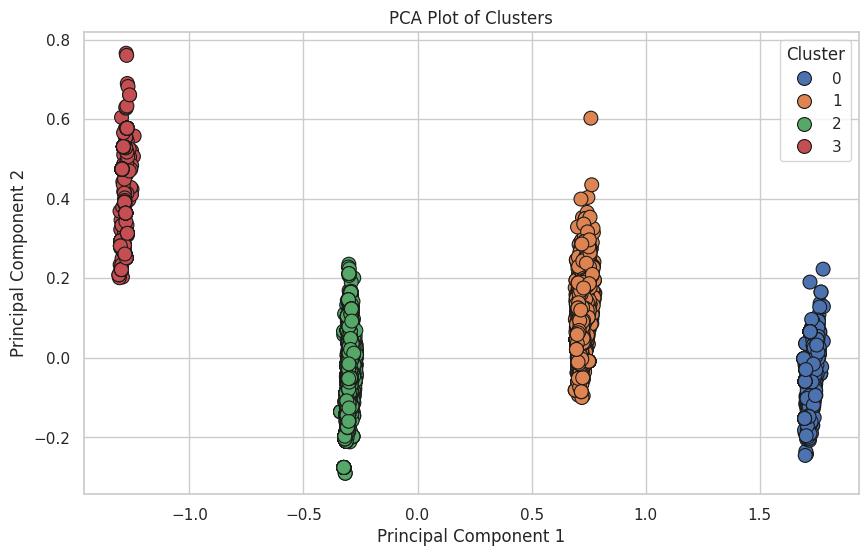

In [62]:
# Plot the clusters using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='principal_component_1', y='principal_component_2', hue='cluster', palette='deep', style='cluster', s=100, edgecolor='k', markers= 'o')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Plot of Clusters')
plt.legend(title='Cluster')
plt.show()

In [63]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15145 entries, 0 to 15144
Data columns (total 12 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Carbon monoxide - Past 15 Years                                  15145 non-null  float64
 1   Ammonia (total) - Past 15 Years                                  15145 non-null  float64
 2   Sulphur dioxide - Past 15 Years                                  15145 non-null  float64
 3   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      15145 non-null  float64
 4   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    15145 non-null  float64
 5   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  15145 non-null  float64
 6   Volatile Organic Compounds (Total) - Past 15 Years               15145 non-null  float64
 7   median_instability_2021                 

In [64]:
# Here we add the categorical features back to the data
industry_titles = industry_titles.reset_index(drop=True)
Province = Province.reset_index(drop=True)
geometry = geometry.reset_index(drop=True)
npri_id = npri_id.reset_index(drop=True)
final_data = final_data.reset_index(drop=True)

In [65]:
final_data['industry_type'] = industry_titles

final_data['Province'] = Province

final_data['geometry'] = geometry

final_data = pd.concat([npri_id, final_data], axis=1)

In [66]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15145 entries, 0 to 15144
Data columns (total 16 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           15145 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  15145 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  15145 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  15145 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      15145 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    15145 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  15145 non-null  float64
 7   Volatile Organic Compounds (Total) - Pas

## In the following section we prepare the null emission data frame and then we finally merge it back to the final data.

In [67]:
null_emission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7794 entries, 2 to 23213
Data columns (total 16 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           7794 non-null   float64
 1   Carbon monoxide - Past 15 Years                                  7794 non-null   float64
 2   Ammonia (total) - Past 15 Years                                  7794 non-null   float64
 3   Sulphur dioxide - Past 15 Years                                  7794 non-null   float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      7794 non-null   float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    7794 non-null   float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  7794 non-null   float64
 7   Volatile Organic Compounds (Total) - Past 15 Y

In [68]:
# Renaming columns in null_emission to match final_df
null_emission = null_emission.rename(columns={
    "NAICSTitleEn": "industry_type",
    "geom": "geometry"
})

In [69]:
# Reordering columns in null_emission to match final_data
null_emission = null_emission[final_data.columns]

# Appending null_emission to final_data using pd.concat
final_data = pd.concat([final_data, null_emission], ignore_index=True)


In [70]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22939 entries, 0 to 22938
Data columns (total 16 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           22939 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  22939 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  22939 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  22939 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      22939 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    22939 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  22939 non-null  float64
 7   Volatile Organic Compounds (Total) - Pas

## In this section the variable 'filtered_data' refers to the dataframe which has the raw values for all the features.

In [71]:
# Renaming columns in null_emission to match final_df
filtered_data = filtered_data.rename(columns={
    "NAICSTitleEn": "industry_type",
    "geom": "geometry"
})

In [72]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22939 entries, 0 to 23223
Data columns (total 15 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           22939 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  22939 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  22939 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  22939 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      22939 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    22939 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  22939 non-null  float64
 7   Volatile Organic Compounds (Total) - Past 15 

In [73]:
# Perform a left join on 'NpriID' to add the 'Cluster' column from final_data to filtered_data
merged_data = filtered_data.merge(final_data[['NpriID', 'Cluster']], on='NpriID', how='left')

In [74]:
merged_data.shape

(22939, 16)

In [75]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22939 entries, 0 to 22938
Data columns (total 16 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   NpriID                                                           22939 non-null  float64
 1   Carbon monoxide - Past 15 Years                                  22939 non-null  float64
 2   Ammonia (total) - Past 15 Years                                  22939 non-null  float64
 3   Sulphur dioxide - Past 15 Years                                  22939 non-null  float64
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      22939 non-null  float64
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    22939 non-null  float64
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  22939 non-null  float64
 7   Volatile Organic Compounds (Total) - Pas

#**Results**

## The below displayed bar chart illustrates the distribution of the top 10 industry types across the five clusters identified in the analysis. It is important to note that the x-axes differ for each cluster, this variation highlights how some clusters are more heavily dominated by certain industries than others. Each pollutant's percentage contribution is calculated across the entire country.


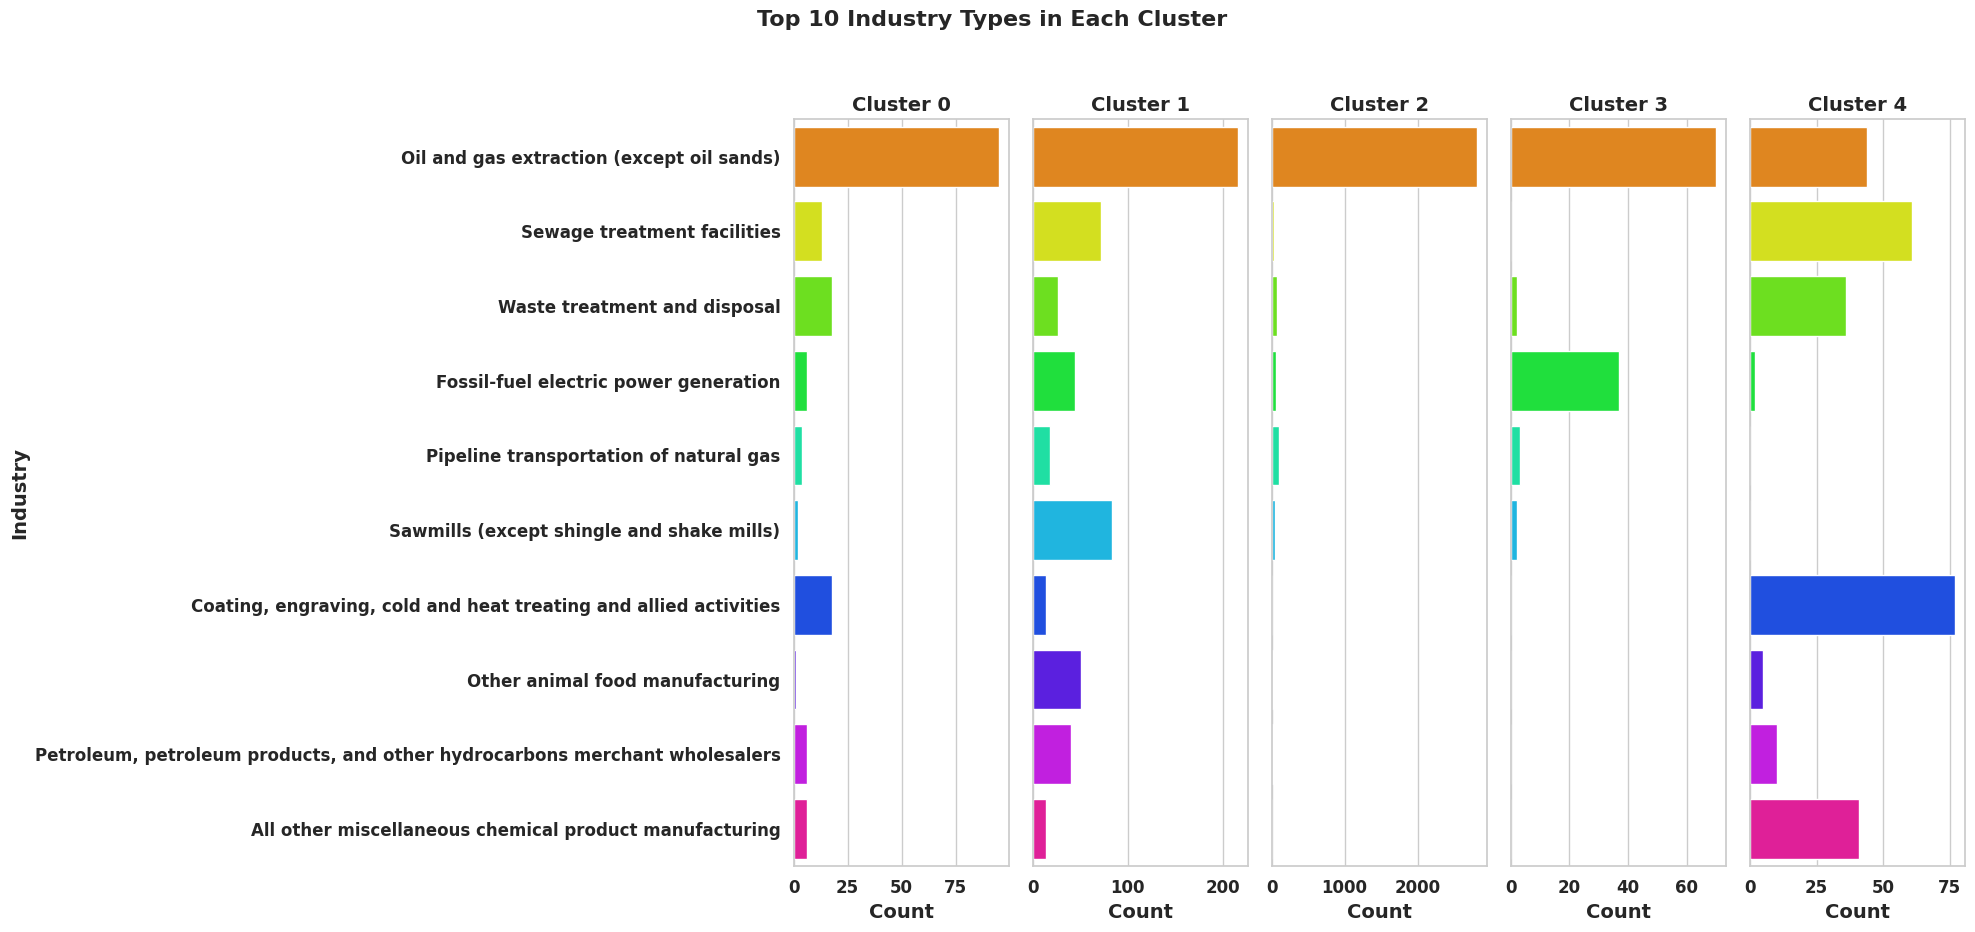

In [76]:
# Filter out rows where industry_type is 0
filtered_data = final_data[final_data['industry_type'] != 0]

# Get the top 10 industries by count
top_10_industries = filtered_data['industry_type'].value_counts().head(10).index

# Filter the dataframe to only include the top 10 industries
filtered_data = filtered_data[filtered_data['industry_type'].isin(top_10_industries)]

# Calculate the frequency of each industry in each cluster
frequency_data = []
for cluster in filtered_data['Cluster'].unique():
    cluster_data = filtered_data[filtered_data['Cluster'] == cluster]
    industry_counts = cluster_data['industry_type'].value_counts()
    for industry in top_10_industries:
        count = industry_counts.get(industry, 0)
        frequency_data.append({
            'Cluster': cluster,
            'Industry': industry,
            'Count': count
        })


frequency_df = pd.DataFrame(frequency_data)
sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=len(filtered_data['Cluster'].unique()), sharey=True, figsize=(20, 10))
industry_colors = sns.color_palette("hsv", len(top_10_industries))

# Plot each cluster in separate subplots
for i, cluster in enumerate(sorted(filtered_data['Cluster'].unique())):
    sns.barplot(
        y='Industry',
        x='Count',
        data=frequency_df[frequency_df['Cluster'] == cluster],
        ax=axes[i],
        palette=industry_colors
    )
    axes[i].set_title(f'Cluster {cluster}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Count", fontsize=14, fontweight='bold')
    if i == 0:
        axes[i].set_ylabel('Industry', fontsize=14, fontweight='bold')
    else:
        axes[i].set_ylabel('')
    for label in axes[i].get_yticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')
    for label in axes[i].get_xticklabels():
        label.set_fontsize(12)
        label.set_fontweight('bold')

plt.suptitle('Top 10 Industry Types in Each Cluster', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [77]:
# Here we define the feature list that can be used to calculate summary statistics

features = ["Carbon monoxide - Past 15 Years", "Ammonia (total) - Past 15 Years", "Sulphur dioxide - Past 15 Years","PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years",
                         "PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years","Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years",
                         "Volatile Organic Compounds (Total) - Past 15 Years", "median_instability_2021", "median_dependency_2021",
                         "median_composition_2021", "median_vulnerability_2021"]

#Summary Statistics

## Here all the features in the data have been aggregated based on the cluster labels.

## This table is significant as it provides a clear overview of the primary pollutants and social deprivation scores within each cluster, enabling a better understanding of the environmental and demographic characteristics that define each cluster.

## The following table show the summary statistics for the scaled data.

In [78]:
summary = final_data.groupby(by=["Cluster"])[features].mean()
summary

,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021
Cluster,,,,,,,,,,,
0,0.000181,0.000694,0.000091,0.000266,0.000489,0.001133,0.002535,0.318705,0.626885,0.359294,0.225343
1,0.001494,0.001512,0.001599,0.001413,0.002654,0.002976,0.003588,0.514555,0.319266,0.402199,0.212049
2,0.000479,0.000351,0.000452,0.000857,0.000879,0.002067,0.001482,0.254822,0.264337,0.341198,0.201818
3,0.000265,0.000054,0.000059,0.001810,0.001710,0.001673,0.003821,0.340344,0.329161,0.438736,0.680230
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.387409,-0.271099,-0.182029,0.105329


## The following table show the summary statistics for the raw data.

In [79]:
summary_raw = merged_data.groupby(by=["Cluster"])[features].mean()
summary_raw

,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021
Cluster,,,,,,,,,,,
0,2.385574e+05,21592.843149,1.328391e+05,35318.067996,19122.094042,295745.526354,17267.799511,-0.562497,1.171824,-0.265320,0.285539
1,1.965168e+06,47065.687682,2.339285e+06,187942.831296,103854.220092,776662.660043,24435.851081,0.286522,-0.464484,0.044226,0.166318
2,6.294932e+05,10942.151839,6.616076e+05,113964.219938,34399.072849,539611.642366,10096.663011,-0.839434,-0.756661,-0.395880,0.074569
3,3.480059e+05,1671.515603,8.557483e+04,240781.679460,66902.623404,436620.348013,26023.572971,-0.468689,-0.411846,0.307832,4.364919
4,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-0.387409,-0.271099,-0.182029,0.105329


## Bivariate maps

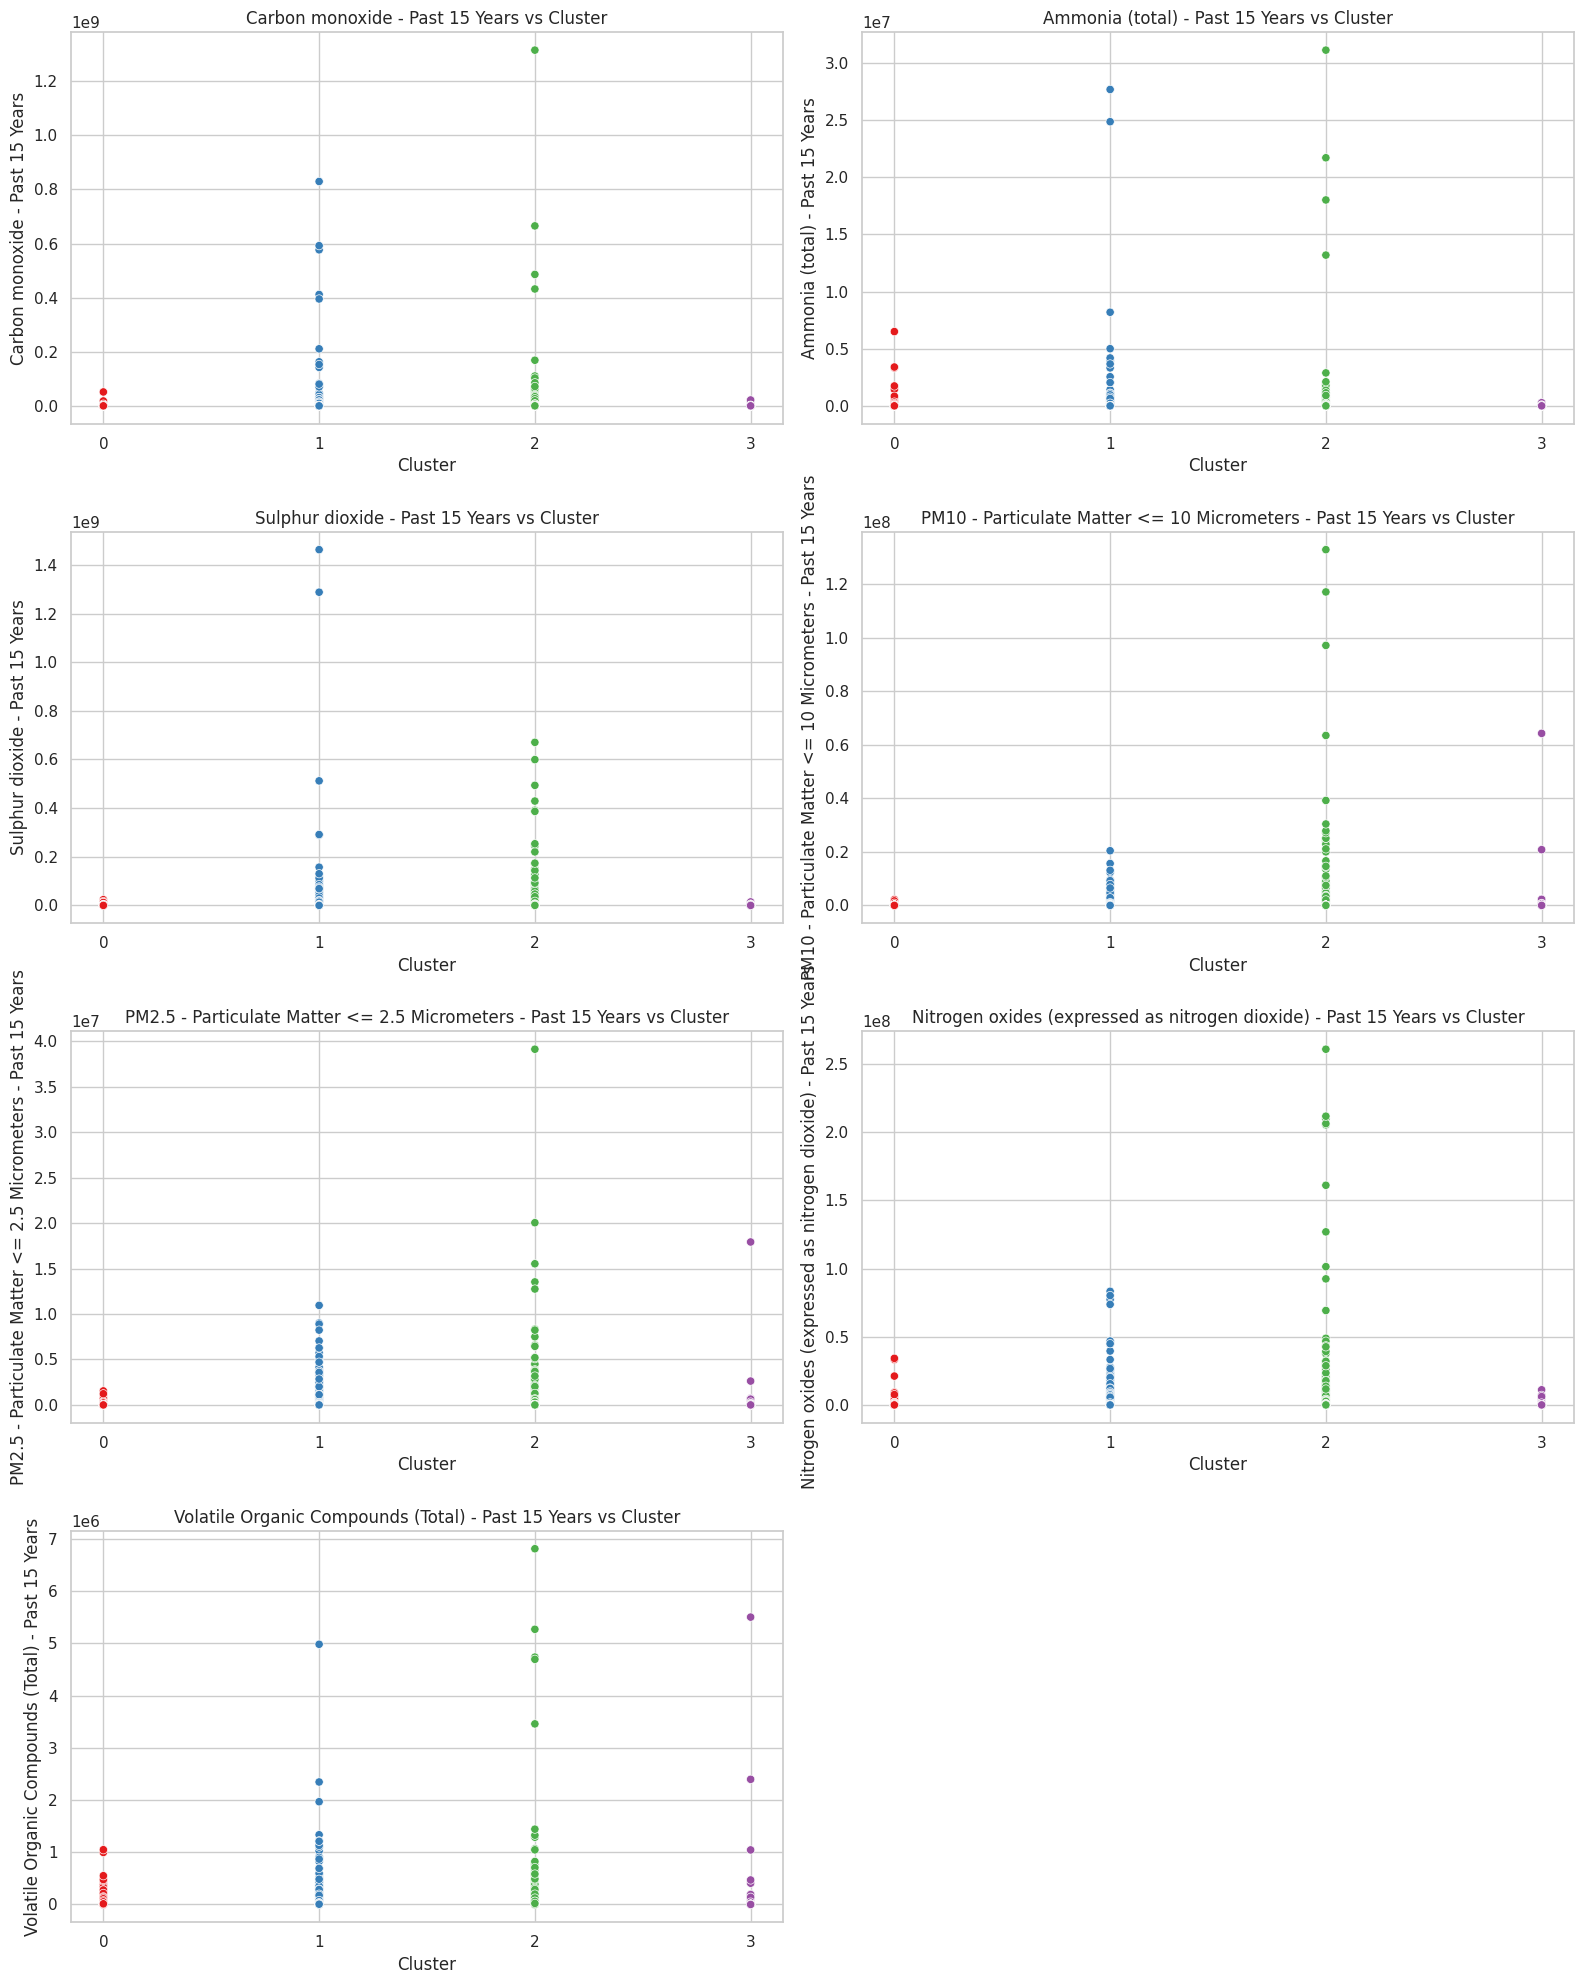

In [80]:
# Assuming clean_data is already a pandas DataFrame

def plot_bivariate(ax, clean_data, pollutant, cluster_col='Cluster'):
    sns.scatterplot(ax=ax, data=clean_data, x=cluster_col, y=pollutant, hue=cluster_col, palette='Set1', legend=False)
    ax.set_title(f'{pollutant} vs {cluster_col}')
    ax.set_xlabel(cluster_col)
    ax.set_ylabel(pollutant)
    ax.set_xticks([0, 1, 2, 3])

# List of pollutant columns
pollutants = [
    "Carbon monoxide - Past 15 Years",
    "Ammonia (total) - Past 15 Years",
    "Sulphur dioxide - Past 15 Years",
    "PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years",
    "PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years",
    "Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years",
    "Volatile Organic Compounds (Total) - Past 15 Years"
]

num_plots = len(pollutants)
cols = 2
rows = (num_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
if rows > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for ax, pollutant in zip(axes, pollutants):
    plot_bivariate(ax, clean_data, pollutant)

for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## In the follwing code block we transform our final dataframe into a GeoDataFrame. Therefore, this data can be downloaded and can plotted on maps using QGIS, by doing this we can understand the geographic concentration of the clusters.

In [81]:
# Here we ensure the geometry column is a string
final_data['geometry'] = final_data['geometry'].astype(str)

# Convert the geometry column from WKB to Shapely objects
final_data['geometry'] = final_data['geometry'].apply(lambda x: wkb.loads(bytes.fromhex(x)))

# Here we convert the DataFrame to a GeoDataFrame
final_data = gpd.GeoDataFrame(final_data, geometry='geometry')

# Next we set a coordinate reference system (CRS)
final_data.set_crs(epsg=3347, inplace=True)


,NpriID,Carbon monoxide - Past 15 Years,Ammonia (total) - Past 15 Years,Sulphur dioxide - Past 15 Years,PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years,PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years,Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years,Volatile Organic Compounds (Total) - Past 15 Years,median_instability_2021,median_dependency_2021,median_composition_2021,median_vulnerability_2021,Cluster,industry_type,Province,geometry
0,1.0,0.028953,0.036555,0.008528,0.034565,0.068643,0.076101,0.033997,0.314185,0.231406,0.412442,0.198048,2,Chemical pulp mills,Alberta,POINT (4902946.056 2297424.066)
1,4.0,0.003605,0.000000,0.000296,0.008439,0.015680,0.001662,0.000000,0.417007,0.256001,0.545889,0.430469,1,0,Manitoba,POINT (5893133.098 1613463.907)
2,11.0,0.000097,0.000011,0.000000,0.000162,0.000369,0.000134,0.007280,0.487963,0.456111,0.353660,0.210077,1,Resin and synthetic rubber manufacturing,Alberta,POINT (4810645.097 2174257.534)
3,15.0,0.000016,0.000000,0.000000,0.000000,0.000077,0.001103,0.008974,0.398997,0.443685,0.445544,0.189613,1,"Coating, engraving, cold and heat treating and...",Ontario,POINT (7204007.428 876801.162)
4,18.0,0.000000,0.000000,0.000000,0.000477,0.000832,0.000000,0.000000,0.523268,0.236217,0.440047,0.182109,1,0,Quebec,POINT (7707040.696 1611670.858)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22934,33869.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.357033,-0.505837,0.434479,0.420154,4,Provincial police services,None,POINT (7200503.063 1031415.451)
22935,33872.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.740329,-0.253777,-0.767860,-0.563824,4,"Concrete pipe, brick and block manufacturing",Ontario,POINT (7184049.734 920736.557)
22936,33874.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.786916,-0.601066,0.399894,-0.297058,4,Provincial police services,Ontario,POINT (7193620.639 1041887.081)
22937,33876.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155972,-0.480020,0.009093,0.156299,4,Motor vehicle body manufacturing,Ontario,POINT (7125051.642 846708.496)


In [82]:
final_data.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 22939 entries, 0 to 22938
Data columns (total 16 columns):
 #   Column                                                           Non-Null Count  Dtype   
---  ------                                                           --------------  -----   
 0   NpriID                                                           22939 non-null  float64 
 1   Carbon monoxide - Past 15 Years                                  22939 non-null  float64 
 2   Ammonia (total) - Past 15 Years                                  22939 non-null  float64 
 3   Sulphur dioxide - Past 15 Years                                  22939 non-null  float64 
 4   PM10 - Particulate Matter <= 10 Micrometers - Past 15 Years      22939 non-null  float64 
 5   PM2.5 - Particulate Matter <= 2.5 Micrometers - Past 15 Years    22939 non-null  float64 
 6   Nitrogen oxides (expressed as nitrogen dioxide) - Past 15 Years  22939 non-null  float64 
 7   Volatile Organic Compou

In [83]:
#Download the geopandas dataframe as gpkg
final_data.to_file("final_data.gpkg", layer='data', driver="GPKG")

#**Conclusion**

## *  Conducted clustering analysis to identify key industries and geographic areas contributing to environmental injustice in Canada.

## *   By combining the National Pollutant Release Inventory (NPRI) with the Canadian Index of Multiple Deprivation (CIMD), derived important insights by examining the clusters and its corresponding attributes.

## *   Implementing social support and economic development programs in vulnerable communities is recommended to enhance their resilience against environmental hazards.


## *   Enhancing the data used in the analysis by integrating additional data sources would improve the study's overall quality and comprehensiveness.


## *   Finally, employing advanced machine learning techniques could refine the clustering analysis, allowing for the identification of more complex patterns and interactions between environmental and social factors, leading to more actionable insights for policymakers and communities.






